# Benchmark Multilingua

numero di samples: 1530 in 3 lingue diverse.

per ogni lingua(1530/3 = 510 samples) abbiamo:
- 300 samples con lunghezze di conversazioni variabili (flow)
- 200 samples con correzioni fatte da parte del tecnico con una lunghezza di conversazione variabile (edge_why)
- 10 samples con messaggi del tecnico casuali(edge_random)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast

In [2]:
RESULT_1 = "../data/second_test/results/results_edge_flow_1.csv"
RESULT_2 = "../data/second_test/results/results_edge_flow_2.csv"
RESULT_3 = "../data/second_test/results/results_edge_flow_3.csv"
RESULT_4 = "../data/second_test/results/results_edge_flow_4.csv"
RESULT_5 = "../data/second_test/results/results_edge_flow_5.csv"


models = ['qwen3', 'granite4']
df_1 = pd.read_csv(RESULT_1)
df_2 = pd.read_csv(RESULT_2)
df_3 = pd.read_csv(RESULT_3)
df_4 = pd.read_csv(RESULT_4)
df_5 = pd.read_csv(RESULT_5)
df = pd.concat([df_1, df_2, df_3, df_4, df_5], ignore_index=True)
colors= ['gray', 'blue', 'orange','yellow','brown']


In [3]:
df.columns

Index(['indice', 'model', 'language', 'messaggi', 'ore_ordinarie_true',
       'ore_straordinarie_true', 'ore_viaggio_true', 'note_true',
       'inefficiency_true', 'inefficiency_note_true', 'chat_context',
       'context_window', 'function_calls', 'push_data_response',
       'ore_ordinarie_acc', 'ore_straordinarie_acc', 'ore_viaggio_acc',
       'inefficiency_acc', 'tot_acc', 'total_duration', 'load_duration_chat',
       'prompt_eval_duration_chat', 'eval_duration_chat', 'eval_count_chat',
       'load_duration_extractor', 'prompt_eval_duration_extractor',
       'eval_duration_extractor', 'eval_count_extractor',
       'ore_ordinarie_predict', 'ore_straordinarie_predict',
       'ore_viaggio_predict', 'note_predict', 'inefficiency_predict',
       'inefficiency_note_predict', 'REF_INDICE', 'L_MESSAGGI', 'TYPE_EVAL',
       'W_MESSAGGI'],
      dtype='object')

In [4]:
print(df.groupby(['model'])['indice'].count())
df.groupby(['language','TYPE_EVAL'])['indice'].count()

model
granite4    7650
qwen3       7650
Name: indice, dtype: int64


language  TYPE_EVAL  
english   edge_random     100
          edge_why       2000
          flow           3000
italian   edge_random     100
          edge_why       2000
          flow           3000
spanish   edge_random     100
          edge_why       2000
          flow           3000
Name: indice, dtype: int64

## Aggiungi colonne: 'count_function_calls' e 'failure_reason'

In [5]:
def func_call(str_list):
    l = ast.literal_eval(str_list)
    return len(l)
    
df['count_function_calls'] = df['function_calls'].apply(func_call)

df['count_function_calls'].unique()

array([4, 3, 5, 2, 1, 0])

In [6]:
""" indetificare quali sono i risultati con errori (escludendo se mancano commenti per ora)
    il caso di errore dipende dalla TYPE_EVAL:
    - flow: 
        - se il numero di count_function_calls non è uguale al numero di messaggi del campione
        - se l'ultima function call non è una push_data con valore True
    - edge_why:
        - se il numero di count_function_calls non è uguale al numero di messaggi del campione
        - se l'ultima function call non è una push_data con valore True
    - edge_random:
        - qua non c'è proprio un caso d'errore definito, va bene un pò tutto     
 """
def func_failure(row):
    len_msg = row['L_MESSAGGI']
    if row['count_function_calls'] != len_msg:
        # controlliamo che l'ultima function call è push_data:
        l = ast.literal_eval(row['function_calls'])
        if l and l[-1] != 'push_data':
            return "Agent don't finish with push_data"
        return "function calls disalignment with the messages"
    # controlliamo che l'ultima function call è push_data:
    l = ast.literal_eval(row['function_calls'])
    if l[-1] != 'push_data':
        return "Agent don't finish with push_data"
    else:
        match row['push_data_response']:
                case True:
                    return None
                case '1.0': return "push_data_response is a string"
                case 'True': return "push_data_response is a string"
                case 'False': return "Agent put False as params in push_data"
                case _: return "push_data_response is null"

df['failure_reason'] = df.loc[df['TYPE_EVAL'] != 'edge_random'].apply(func_failure, axis=1)


In [7]:
print(f"passed sample: {df['failure_reason'].isna().sum()}/{len(df)}")
df.groupby(['failure_reason'])['indice'].count()

passed sample: 12766/15300


failure_reason
Agent don't finish with push_data                1858
function calls disalignment with the messages     540
push_data_response is null                        136
Name: indice, dtype: int64

In [8]:
df.loc[df['failure_reason'] == 'function calls disalignment with the messages'][['count_function_calls','function_calls','TYPE_EVAL', 'L_MESSAGGI']]

,count_function_calls,function_calls,TYPE_EVAL,L_MESSAGGI
9,4,"['extractor_expert', 'extractor_expert', 'extr...",flow,5
44,3,"['extractor_expert', 'extractor_expert', 'push...",flow,4
48,3,"['extractor_expert', 'extractor_expert', 'push...",flow,4
61,3,"['extractor_expert', 'extractor_expert', 'push...",flow,4
65,3,"['extractor_expert', 'extractor_expert', 'push...",flow,5
...,...,...,...,...
15047,2,"['extractor_expert', 'push_data']",flow,3
15062,2,"['extractor_expert', 'push_data']",flow,3
15130,2,"['extractor_expert', 'push_data']",edge_why,3
15173,2,"['extractor_expert', 'push_data']",edge_why,3


# Results

## Accuracy totale delle ore 

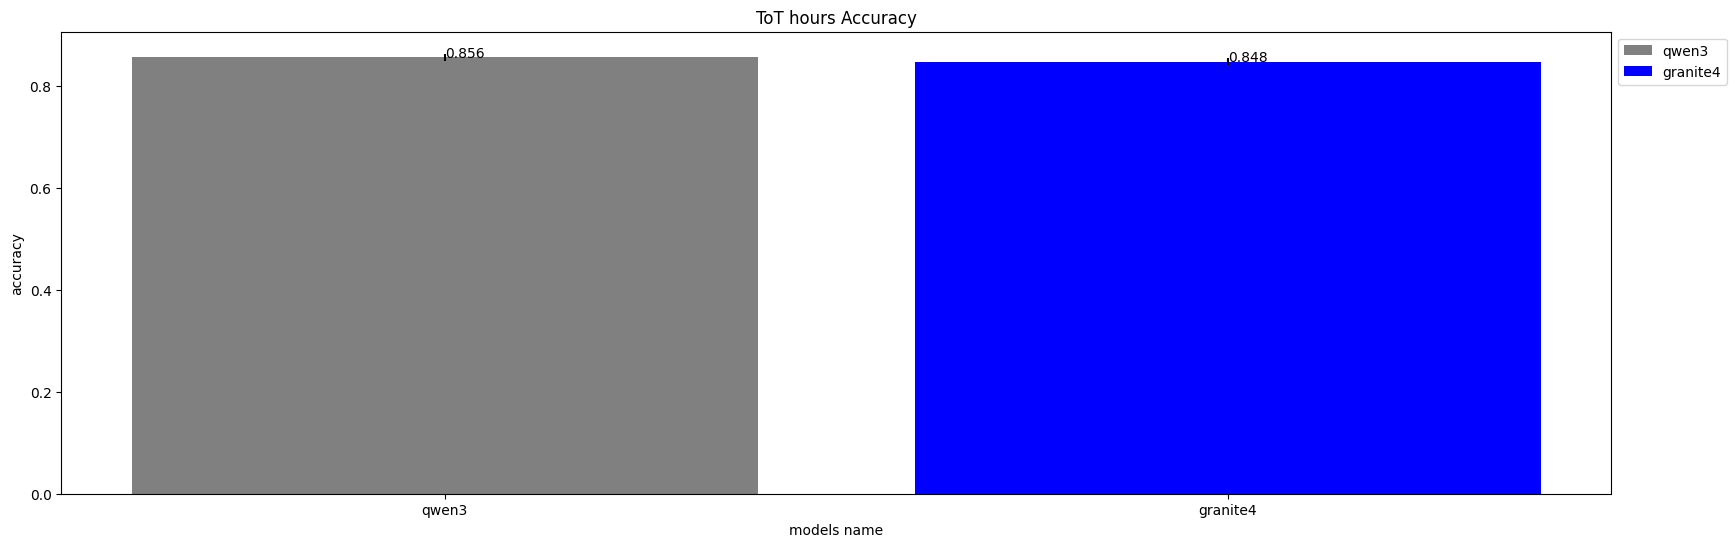

In [10]:
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])

media_group = []
CI_group = []
for model in models:
    acc_media = round(df.loc[(df['model'] == model) & (df['TYPE_EVAL'] != 'edge_random') & (df['failure_reason'].isna())]['tot_acc'].mean(),3)
    n = len(df)
    # intervallo di confidenza al 99 %
    CI = 2.576 * np.sqrt(acc_media * (1- acc_media) / n)
    media_group.append(acc_media)
    CI_group.append(CI)

plt.figure(figsize=(20,6))
plt.bar(models, media_group, yerr=CI_group, color=colors, label=models)
add_labels(models,media_group)
plt.title("ToT hours Accuracy")
plt.xlabel("models name")
plt.ylabel("accuracy")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

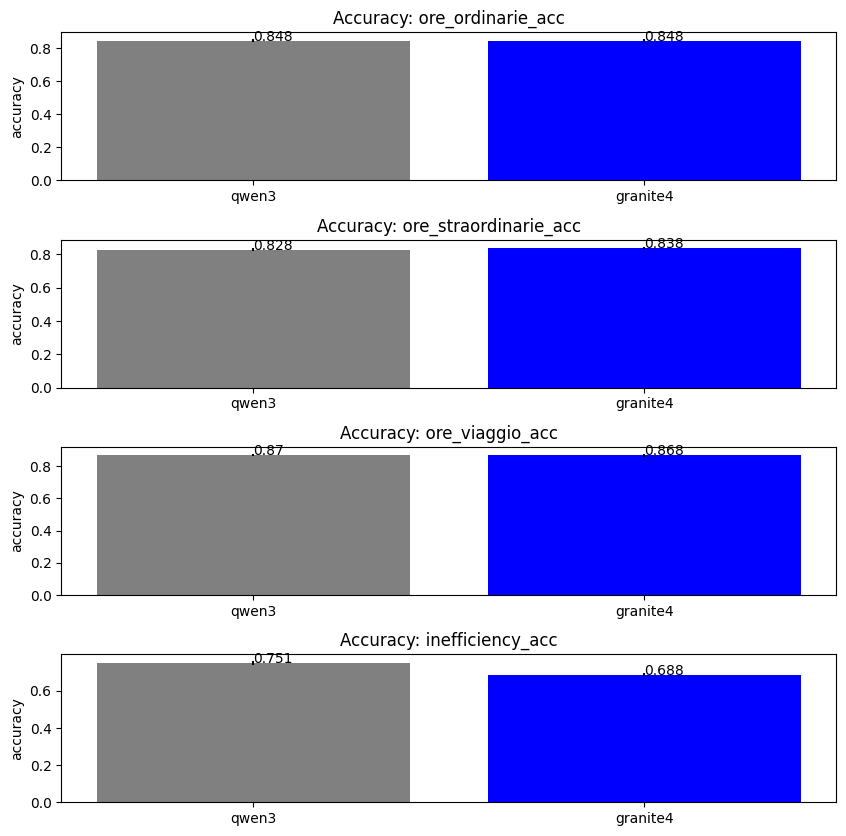

In [11]:
def add_labels_w_axis(ax, labels, vals, offset=0.02):
    for i in range(len(labels)):
        ax.text(i, vals[i], vals[i])

# accuracy per tipo d'orario
def display_ore(cat, z=2.576):
    """
    Display delle ore accuracy
    """
    
    fig, axis = plt.subplots(4)
    fig.set_figheight(10)
    fig.set_figwidth(10)
    for idx,column in enumerate(cat):
        media_group = []
        CI_group = []
        for model in models:
            acc_media = round(df.loc[(df['model'] == model) & (df['TYPE_EVAL'] != 'edge_random') & (df['failure_reason'].isna())][column].mean(),3)
            n = len(df)
            # intervallo di confidenza
            CI = z * np.sqrt(acc_media * (1- acc_media) / n)
            media_group.append(acc_media)
            CI_group.append(CI)
        axis[idx].bar(models, media_group, yerr=CI_group, color=colors, label=models)
        add_labels_w_axis(axis[idx], models, media_group)
        axis[idx].set_title(f'Accuracy: {column}')
        #axis[idx].set_xlabel('models name')
        axis[idx].set_ylabel('accuracy')
        

columns = ['ore_ordinarie_acc', 'ore_straordinarie_acc', 'ore_viaggio_acc','inefficiency_acc']
display_ore(columns)
plt.subplots_adjust(hspace=0.4)
plt.show()

## Accuracy ore con diversi livelli di lunghezza e larghezza dei messaggi

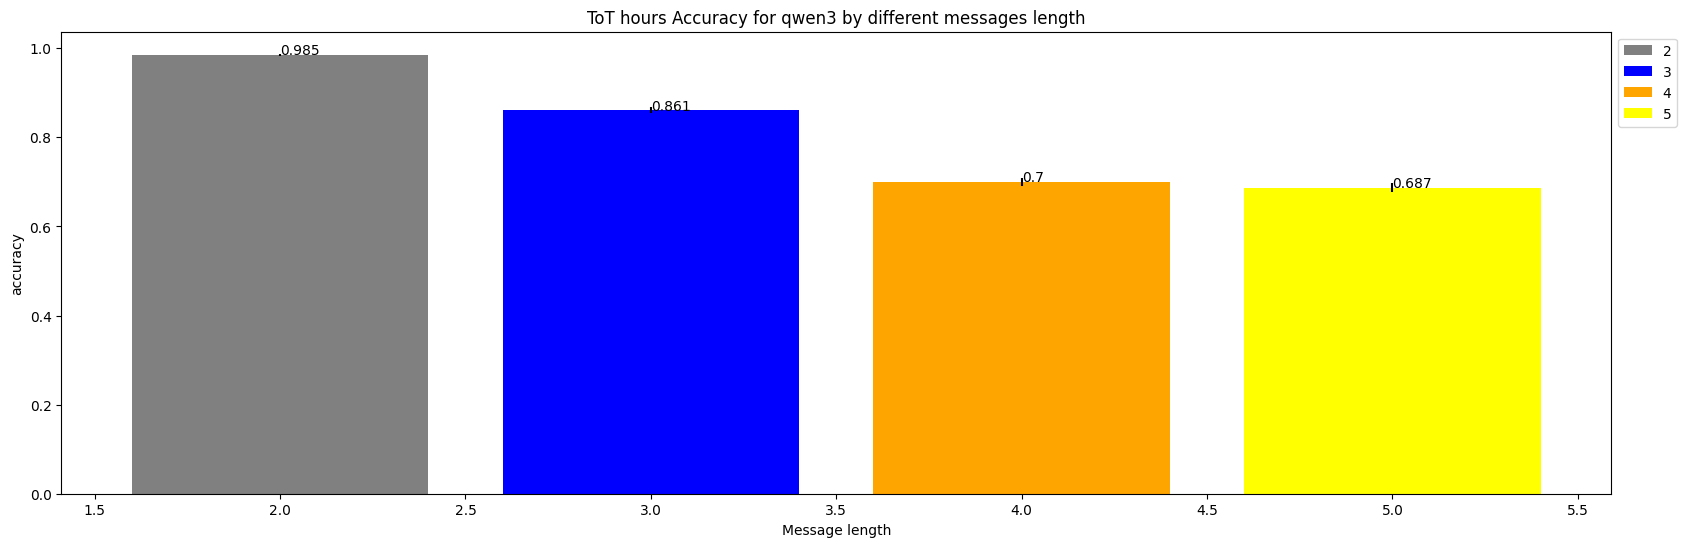

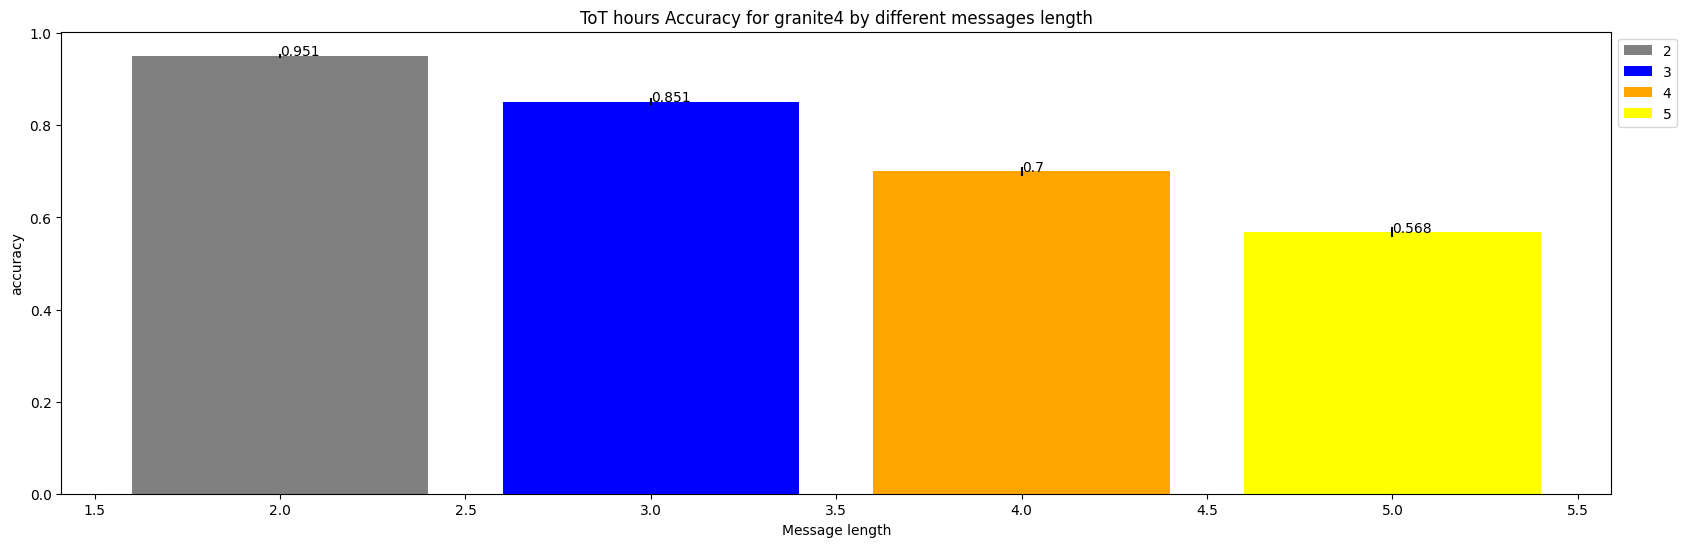

In [12]:
# accuracy a diversi livelli di lunghezza della lista messaggi
def add_labels(labels, vals):
    for i,x_label in enumerate(labels):
        plt.text(x_label,vals[i], vals[i])

# senza la l = 1 perchè è un edge case quello
l_msg = np.sort(df['L_MESSAGGI'].unique())[1:]
for model in models:
    media_group = []
    CI_group = []
    for length_m in l_msg:
        acc_media = round(df.loc[(df['model'] == model) & (df['TYPE_EVAL'] != 'edge_random') & (df['failure_reason'].isna()) & (df['L_MESSAGGI'] == length_m)]['tot_acc'].mean(),3)
        n = len(df)
        # intervallo di confidenza al 99 %
        CI = 2.576 * np.sqrt(acc_media * (1- acc_media) / n)
        media_group.append(acc_media)
        CI_group.append(CI)

    plt.figure(figsize=(20,6))
    plt.bar(l_msg,media_group, yerr=CI_group, color=colors, label=l_msg)
    add_labels(l_msg,media_group)
    plt.title(f"ToT hours Accuracy for {model} by different messages length")
    plt.xlabel("Message length")
    plt.ylabel("accuracy")
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

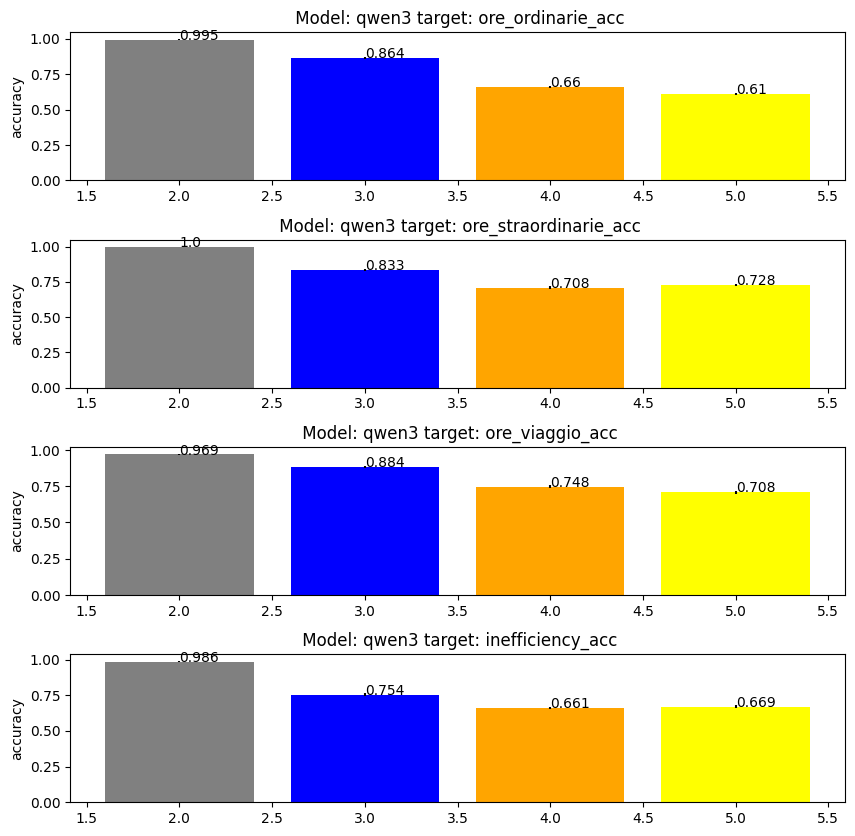

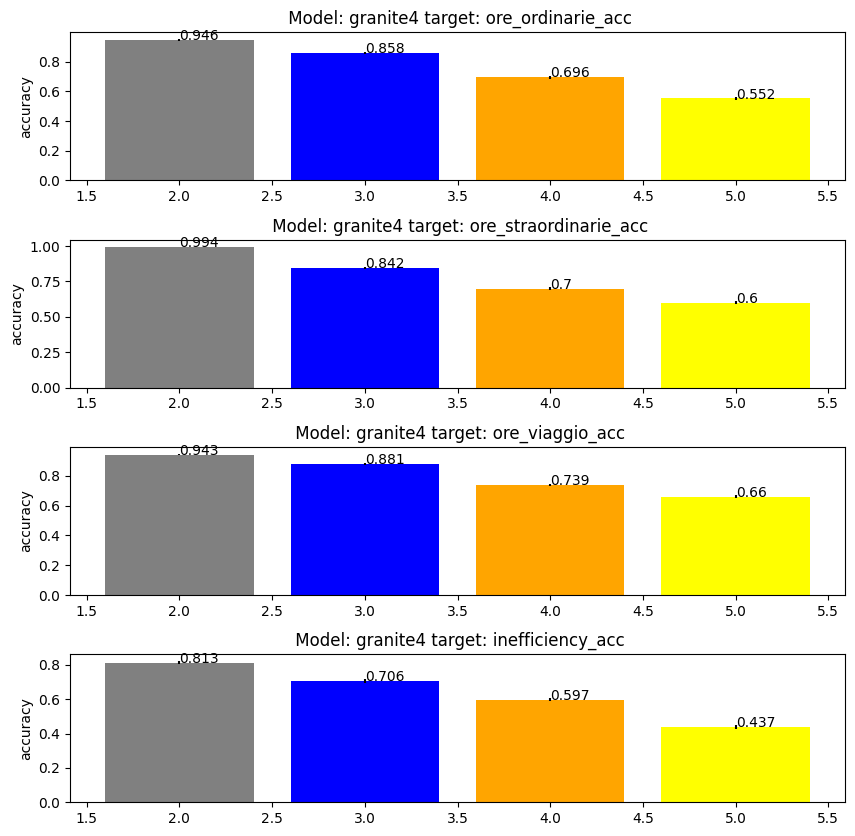

In [13]:
def add_labels_w_axis(ax, labels, vals, offset=0.02):
    for i,x_label in enumerate(labels):
        ax.text(x_label, vals[i], vals[i])

l_msg = np.sort(df['L_MESSAGGI'].unique())[1:]

for model in models:
    # accuracy per tipo d'orario
    def display_ore(cat, z=2.576):
        """
        Display delle ore accuracy
        """
        
        fig, axis = plt.subplots(4)
        fig.set_figheight(10)
        fig.set_figwidth(10)
        for idx,column in enumerate(cat):
            media_group = []
            CI_group = []
            for length_m in l_msg:
                acc_media = round(df.loc[(df['model'] == model) & (df['TYPE_EVAL'] != 'edge_random') & (df['failure_reason'].isna())&(df['L_MESSAGGI'] == length_m)][column].mean(),3)
                n = len(df)
                # intervallo di confidenza
                CI = z * np.sqrt(acc_media * (1- acc_media) / n)
                media_group.append(acc_media)
                CI_group.append(CI)
            axis[idx].bar(l_msg, media_group, yerr=CI_group, color=colors, label=l_msg)
            add_labels_w_axis(axis[idx], l_msg, media_group)
            axis[idx].set_title(f' Model: {model} target: {column}')
            #axis[idx].set_xlabel('models name')
            axis[idx].set_ylabel('accuracy')
            
    
    columns = ['ore_ordinarie_acc', 'ore_straordinarie_acc', 'ore_viaggio_acc','inefficiency_acc']
    display_ore(columns)
    plt.subplots_adjust(hspace=0.4)
    plt.show()

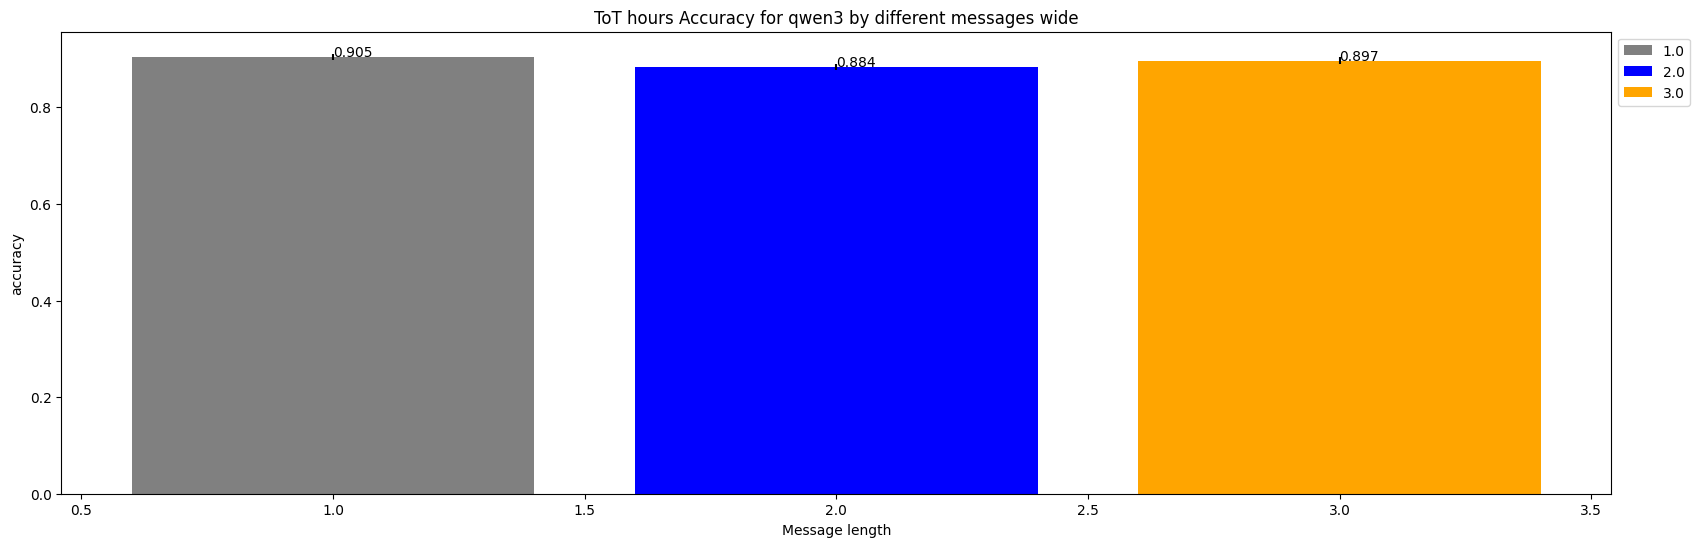

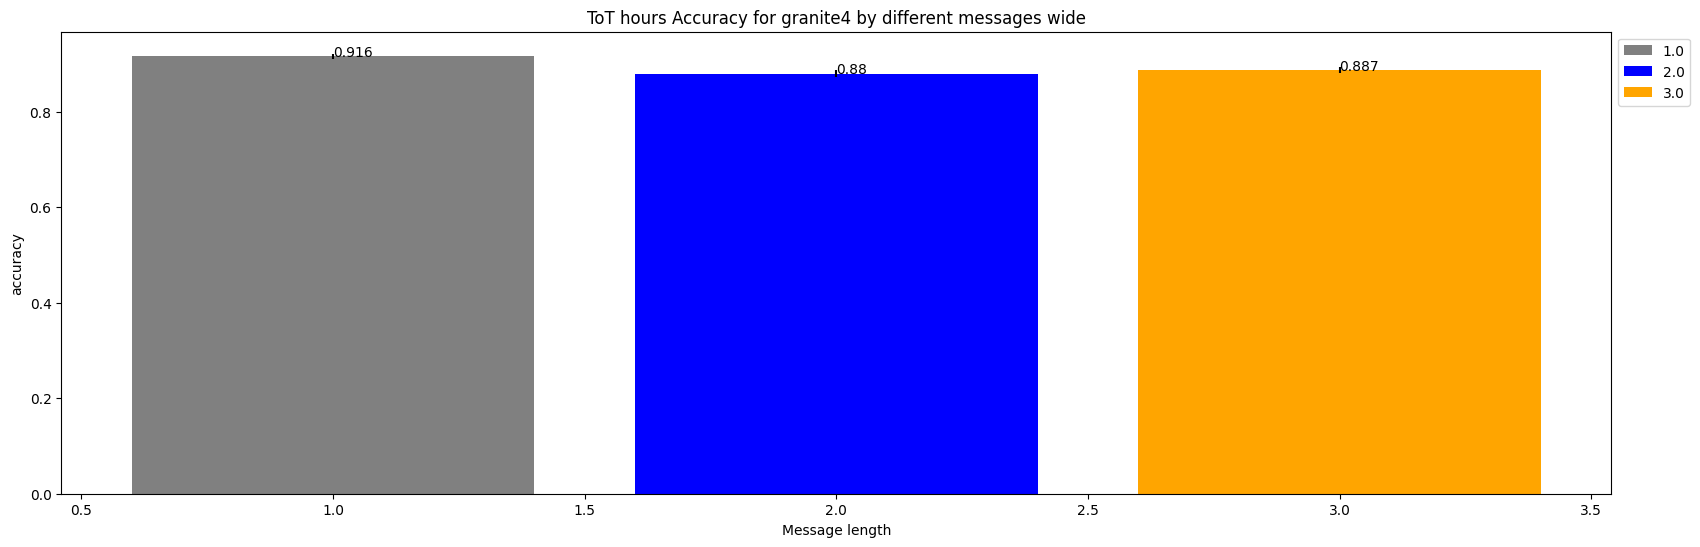

In [14]:
# accuracy a diversi livelli di larghezza dei messaggi ( sono case edge why con L_MESSAGGI == 3)
def add_labels(labels, vals):
    for i,x_label in enumerate(labels):
        plt.text(x_label,vals[i], vals[i])
# rimuviamo l'ultimo elemento che sarà il valore nan
w_msg = np.sort(df['W_MESSAGGI'].unique())[:-1]
for model in models:
    media_group = []
    CI_group = []
    for wide_m in w_msg:
        acc_media = round(df.loc[(df['model'] == model) & (df['TYPE_EVAL'] != 'edge_random') & (df['failure_reason'].isna()) & (df['W_MESSAGGI'] == wide_m)]['tot_acc'].mean(),3)
        n = len(df)
        # intervallo di confidenza al 99 %
        CI = 2.576 * np.sqrt(acc_media * (1- acc_media) / n)
        media_group.append(acc_media)
        CI_group.append(CI)

    plt.figure(figsize=(20,6))
    plt.bar(w_msg,media_group, yerr=CI_group, color=colors, label=w_msg)
    add_labels(w_msg,media_group)
    plt.title(f"ToT hours Accuracy for {model} by different messages wide")
    plt.xlabel("Message length")
    plt.ylabel("accuracy")
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

## inefficiency detection 

 righe true: 15300	 righe predict: 15196


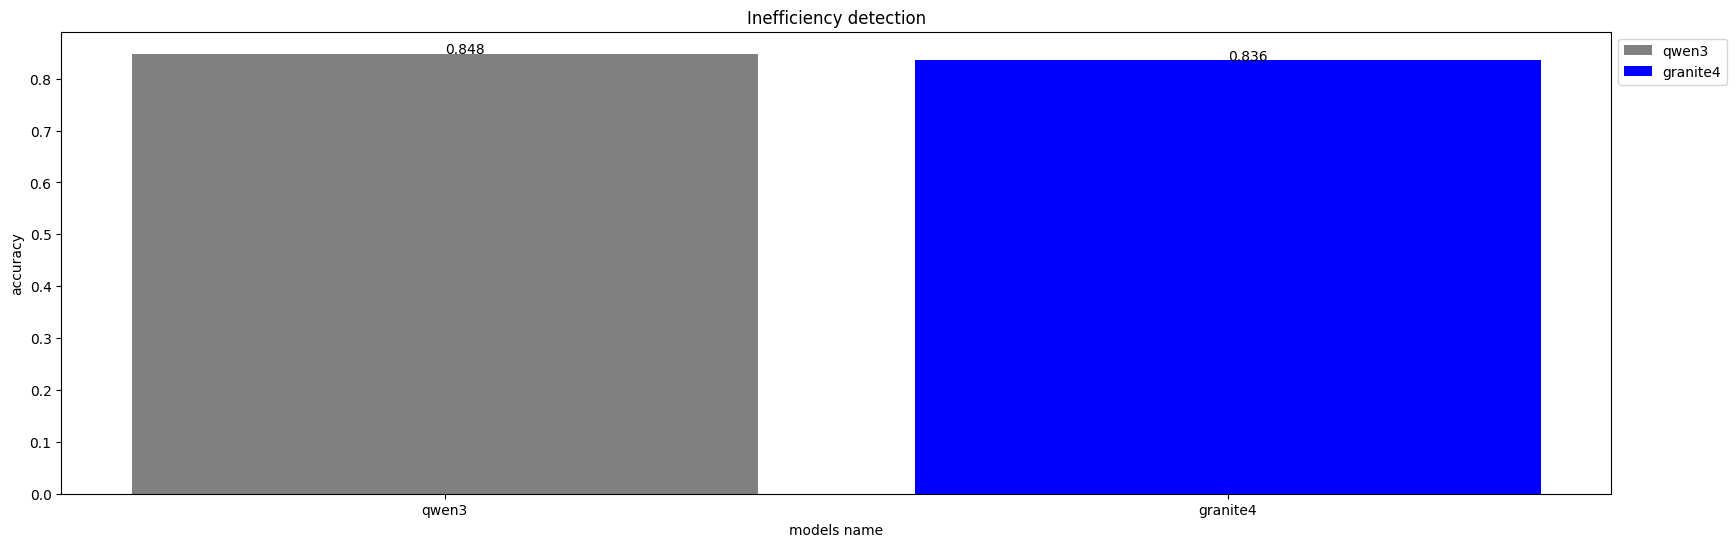

In [15]:
# accuracy in inefficiency detection e inefficiency allucination (vede un inefficienza dove non è presente)
print(f" righe true: {df['inefficiency_true'].count()}\t righe predict: {df['inefficiency_predict'].count()}")

def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])

acc_group = []
for model in models:
    # per ogni riga del dataset controlliamo se semplicemente inefficiency_true e inefficiency_predict sono diversi da zero (senza controllare se hanno gli stessi valori)
    # se inefficiency_true sono entrambi chiamati -> inefficiency detection 
    detection = df.loc[(df['model'] == model) & (df['TYPE_EVAL'] != 'edge_random') & (df['failure_reason'].isna()) & (df['inefficiency_true'] != 0) & (df['inefficiency_predict'] != 0)]['indice'].count()
    acc = round(detection / df.loc[(df['model'] == model) & (df['TYPE_EVAL'] != 'edge_random') & (df['failure_reason'].isna()) & (df['inefficiency_true'] != 0)]['indice'].count(),3)
    acc_group.append(acc)

plt.figure(figsize=(20,6))
plt.bar(models, acc_group, color=colors, label=models)
add_labels(models,acc_group)
plt.title("Inefficiency detection")
plt.xlabel("models name")
plt.ylabel("accuracy")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

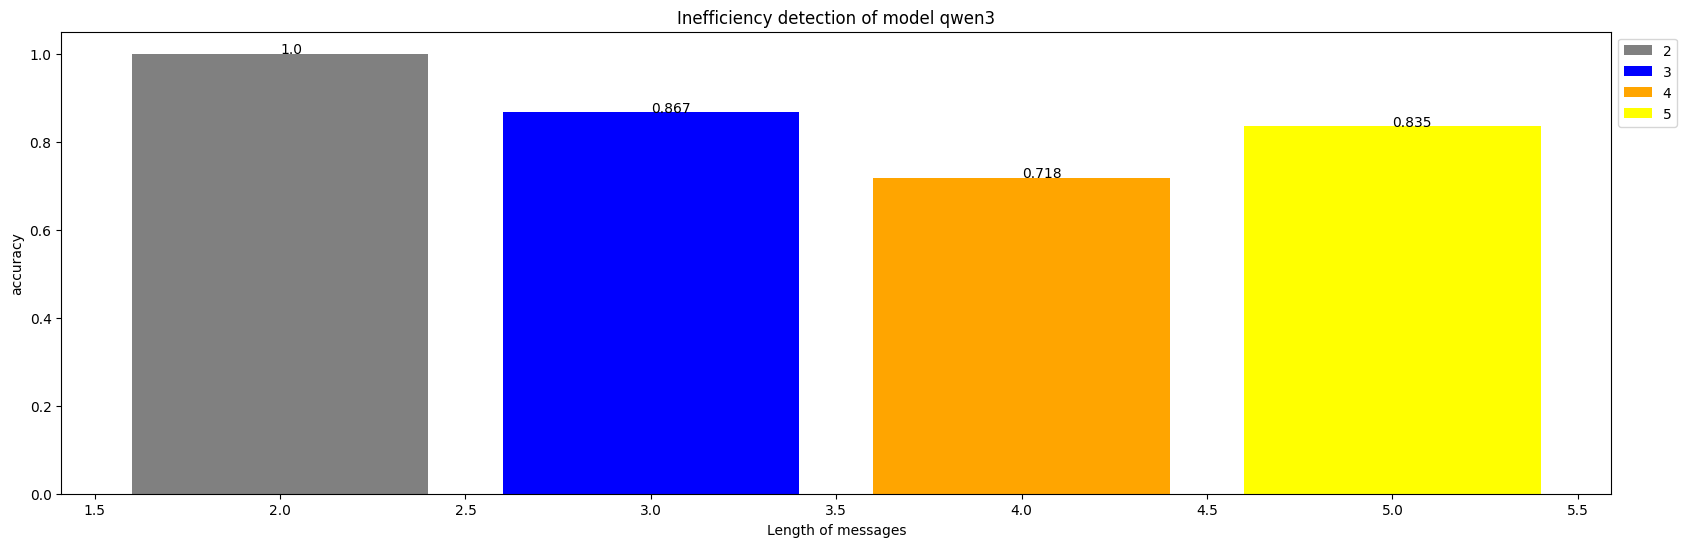

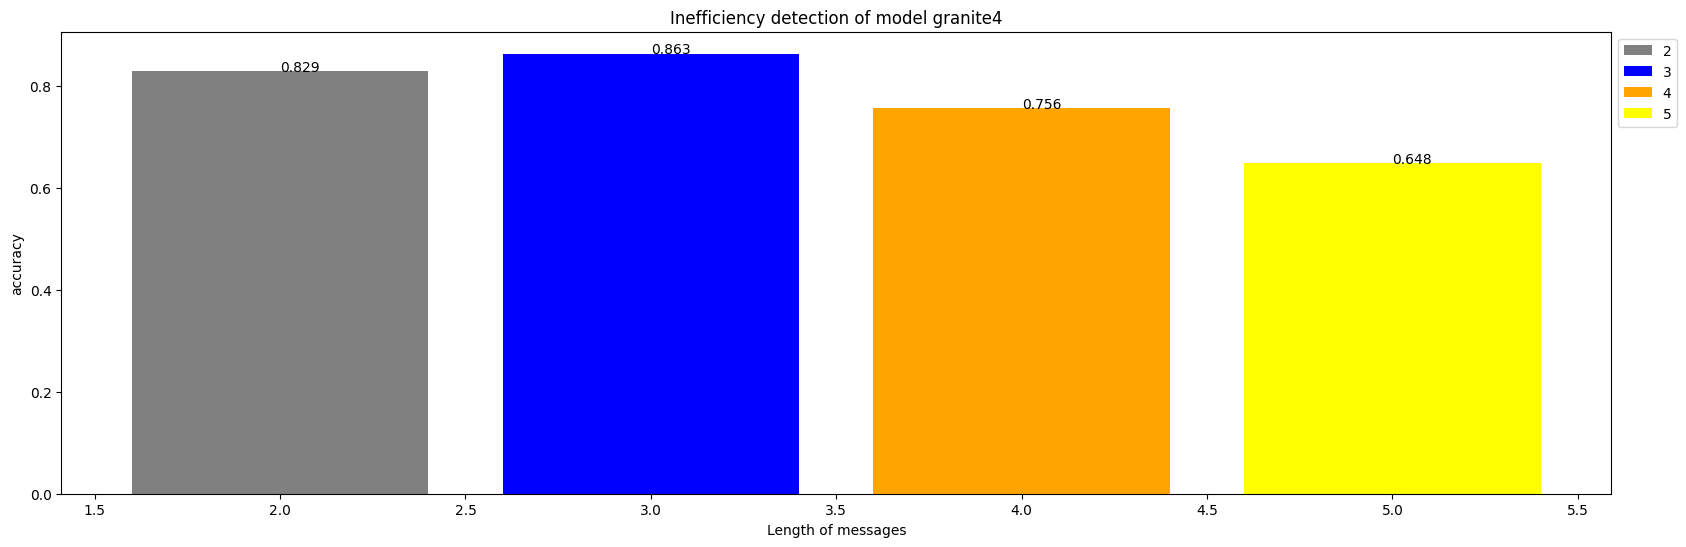

In [16]:
# inefficiency detection a diversi livelli di flow per vedere se si ricorda quando è presente più contesto
def add_labels(labels, vals):
    for i,x_label in enumerate(labels):
        plt.text(x_label,vals[i], vals[i])
# senza la l = 1 perchè è un edge case quello
l_msg = np.sort(df['L_MESSAGGI'].unique())[1:]

for model in models:
    acc_group = []
    for length_m in l_msg:
        detection = df.loc[(df['model'] == model) & (df['TYPE_EVAL'] != 'edge_random') & (df['failure_reason'].isna()) & (df['inefficiency_true'] != 0) & (df['inefficiency_predict'] != 0)  & (df['L_MESSAGGI'] == length_m)]['indice'].count()
        acc = round(detection / df.loc[(df['model'] == model) & (df['TYPE_EVAL'] != 'edge_random') & (df['failure_reason'].isna()) & (df['inefficiency_true'] != 0) & (df['L_MESSAGGI'] == length_m)]['indice'].count(),3)
        acc_group.append(acc)
    plt.figure(figsize=(20,6))
    plt.bar(l_msg, acc_group, color=colors, label=l_msg)
    add_labels(l_msg,acc_group)
    plt.title(f"Inefficiency detection of model {model}")
    plt.xlabel("Length of messages")
    plt.ylabel("accuracy")
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

## inefficiency allucination

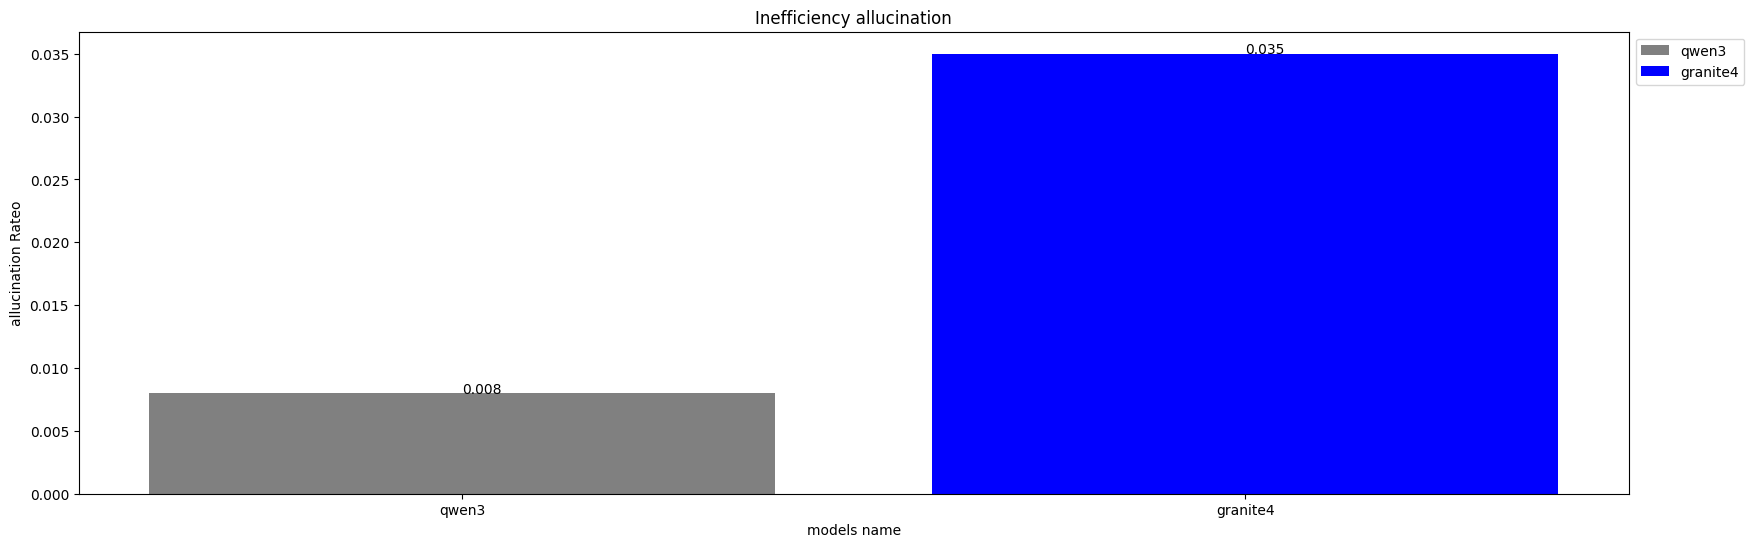

In [17]:
# inefficiency allucination
# se solo inefficiency_predict è stato chiamato mentre inefficiency_true no -> inefficiency allucination
acc_group = []
for model in models:
    allucination = df.loc[(df['model'] == model) & (df['TYPE_EVAL'] != 'edge_random') & (df['failure_reason'].isna()) & (df['inefficiency_true'] == 0) & (df['inefficiency_predict'] != 0)]['indice'].count()
    acc = round(allucination / df.loc[(df['model'] == model) & (df['TYPE_EVAL'] != 'edge_random') & (df['failure_reason'].isna()) & (df['inefficiency_true'] == 0)]['indice'].count(),3)
    acc_group.append(acc)
plt.figure(figsize=(20,6))
plt.bar(models, acc_group, color=colors, label=models)
add_labels(models,acc_group)
plt.title("Inefficiency allucination")
plt.xlabel("models name")
plt.ylabel("allucination Rateo")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

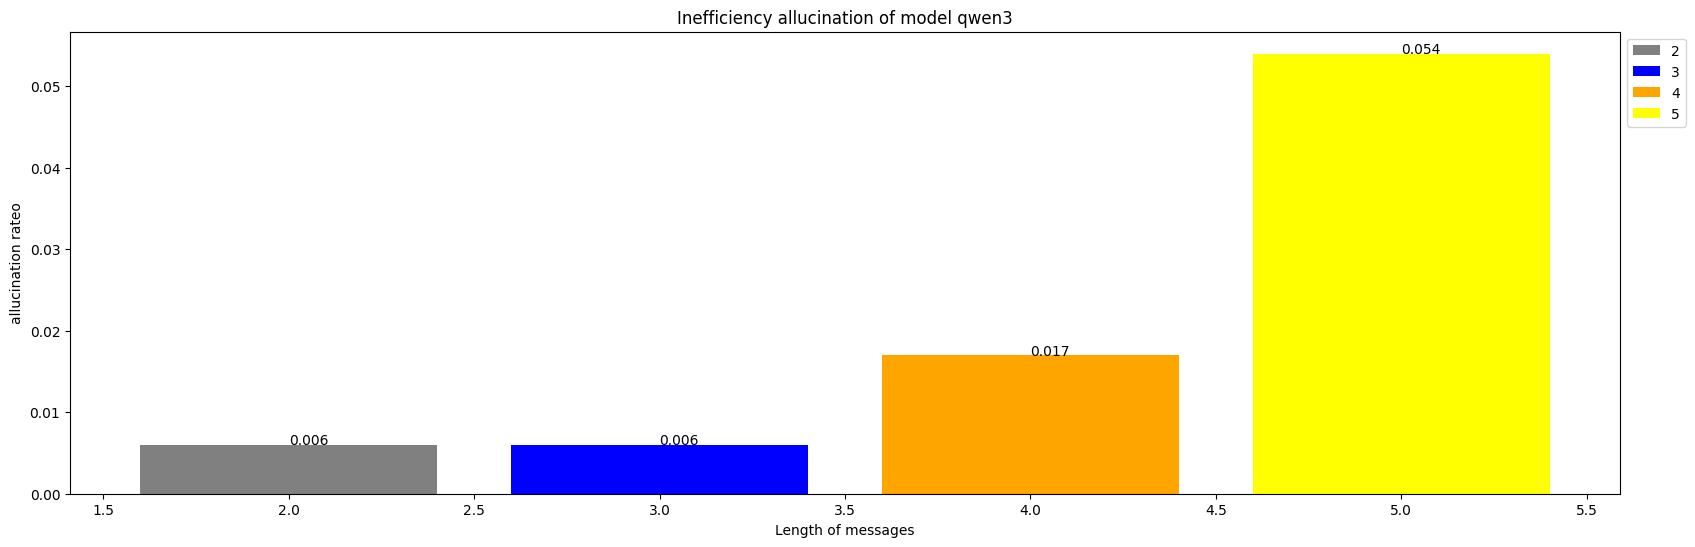

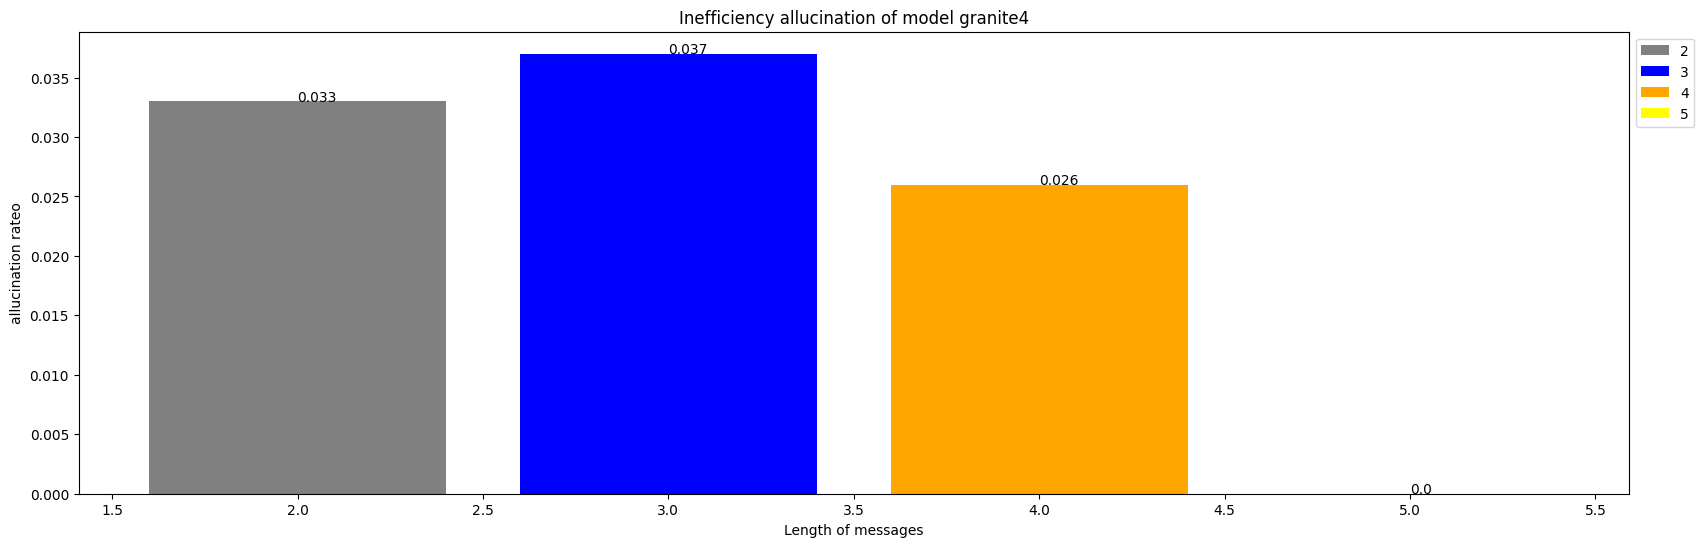

In [18]:
# inefficiency allucination con diversi flow
def add_labels(labels, vals):
    for i,x_label in enumerate(labels):
        plt.text(x_label,vals[i], vals[i])
# senza la l = 1 perchè è un edge case quello
l_msg = np.sort(df['L_MESSAGGI'].unique())[1:]

for model in models:
    acc_group = []
    for length_m in l_msg:
        allucination = df.loc[(df['model'] == model) & (df['TYPE_EVAL'] != 'edge_random') & (df['failure_reason'].isna()) & (df['inefficiency_true'] == 0) & (df['inefficiency_predict'] != 0)  & (df['L_MESSAGGI'] == length_m)]['indice'].count()
        acc = round(allucination / df.loc[(df['model'] == model) & (df['TYPE_EVAL'] != 'edge_random') & (df['failure_reason'].isna()) & (df['inefficiency_true'] == 0) & (df['L_MESSAGGI'] == length_m)]['indice'].count(),3)
        acc_group.append(acc)
    plt.figure(figsize=(20,6))
    plt.bar(l_msg, acc_group, color=colors, label=l_msg)
    add_labels(l_msg,acc_group)
    plt.title(f"Inefficiency allucination of model {model}")
    plt.xlabel("Length of messages")
    plt.ylabel("allucination rateo")
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

## Accuratezza nelle Note & Descrizione inefficiency 
Bisogna tenere conto:
- se il testo è presente nella predizione (detection) 
- se il contenuto della label rispecchia a livello semantico il contenuto della predizione(con Sentence Embeddings e Rouge score) 

In [20]:
df.columns

Index(['indice', 'model', 'language', 'messaggi', 'ore_ordinarie_true',
       'ore_straordinarie_true', 'ore_viaggio_true', 'note_true',
       'inefficiency_true', 'inefficiency_note_true', 'chat_context',
       'context_window', 'function_calls', 'push_data_response',
       'ore_ordinarie_acc', 'ore_straordinarie_acc', 'ore_viaggio_acc',
       'inefficiency_acc', 'tot_acc', 'total_duration', 'load_duration_chat',
       'prompt_eval_duration_chat', 'eval_duration_chat', 'eval_count_chat',
       'load_duration_extractor', 'prompt_eval_duration_extractor',
       'eval_duration_extractor', 'eval_count_extractor',
       'ore_ordinarie_predict', 'ore_straordinarie_predict',
       'ore_viaggio_predict', 'note_predict', 'inefficiency_predict',
       'inefficiency_note_predict', 'REF_INDICE', 'L_MESSAGGI', 'TYPE_EVAL',
       'W_MESSAGGI', 'count_function_calls', 'failure_reason'],
      dtype='object')

In [21]:
df['inefficiency_note_true'].isna().sum()

np.int64(11060)

### se  non è già presente il dataset con le similarità:

In [24]:
from tqdm import tqdm
from sentence_transformers import SentenceTransformer, util 
from rouge_score import rouge_scorer

def add_similarity(data:pd.DataFrame, column_name:str,label_column:str, predict_column:str, metric:str)-> pd.DataFrame:
    """Creare una nuova colonna per fare similarità sul testo"""
    indexes = data.loc[data[label_column].isna() != True].index
    metric_model = None
    if metric == 'sentence_similarity':
        metric_model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-mpnet-base-v2')
    else:
        metric_model = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    for idx in tqdm(indexes):
        label = data.at[idx, label_column]
        pred = str(data.at[idx, predict_column])
        
        if pred == 'nan':
            data.loc[idx,column_name] = 0
        else:
            match metric:
                case 'sentence_similarity':
                    emb_l = metric_model.encode(label)
                    try:
                        emb_p = metric_model.encode(pred)
                    except TypeError as e:
                        Exception(f"errore nel fare l'embdedding di {pred}\t {e}")
                    data.loc[idx,column_name] = round(util.cos_sim(emb_l, emb_p).item(),3)
                case 'rouge':
                    scores = metric_model.score(label, pred)
                    data.loc[idx, column_name] = round(scores['rougeL'].fmeasure,3)
    return data


In [25]:
df = add_similarity(df, "sentence_similarity_score_note", "note_true","note_predict","sentence_similarity")

  1%|          | 104/13330 [00:14<31:34,  6.98it/s]


KeyboardInterrupt: 

### Altrimenti

In [26]:
df = pd.read_csv('../data/second_test/results/results_with_similarity_text.csv')

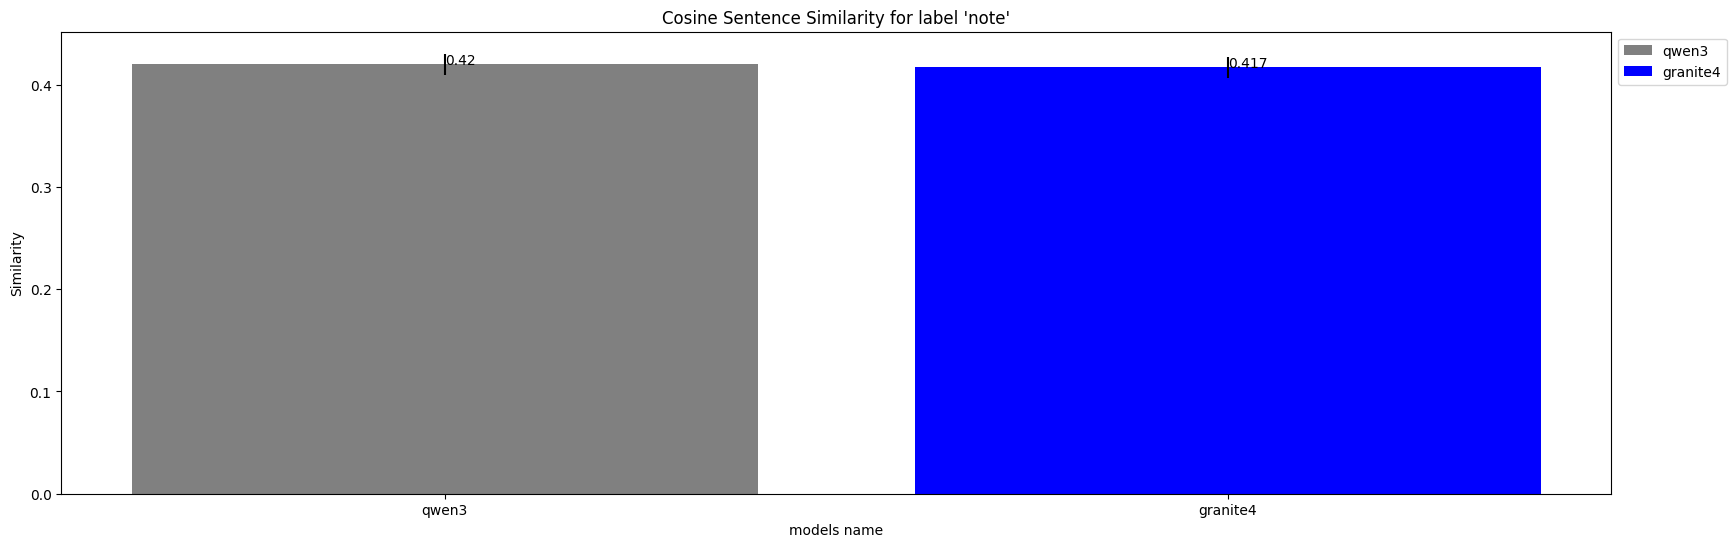

In [27]:
# cosine similarity del campo note con Sentence similarity
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])
media_group = []
CI_group = []
for model in models:
    acc_media = round(df.loc[(df['model'] == model) & (df['TYPE_EVAL'] != 'edge_random') & (df['failure_reason'].isna()) & (df['sentence_similarity_score_note'].isna() != True)]['sentence_similarity_score_note'].mean(),3)
    n = len(df)
    # intervallo di confidenza al 99 %
    CI = 2.576 * np.sqrt(acc_media * (1- acc_media) / n)
    media_group.append(acc_media)
    CI_group.append(CI)

plt.figure(figsize=(20,6))
plt.bar(models, media_group, yerr=CI_group, color=colors, label=models)
add_labels(models,media_group)
plt.title("Cosine Sentence Similarity for label 'note'")
plt.xlabel("models name")
plt.ylabel("Similarity")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))


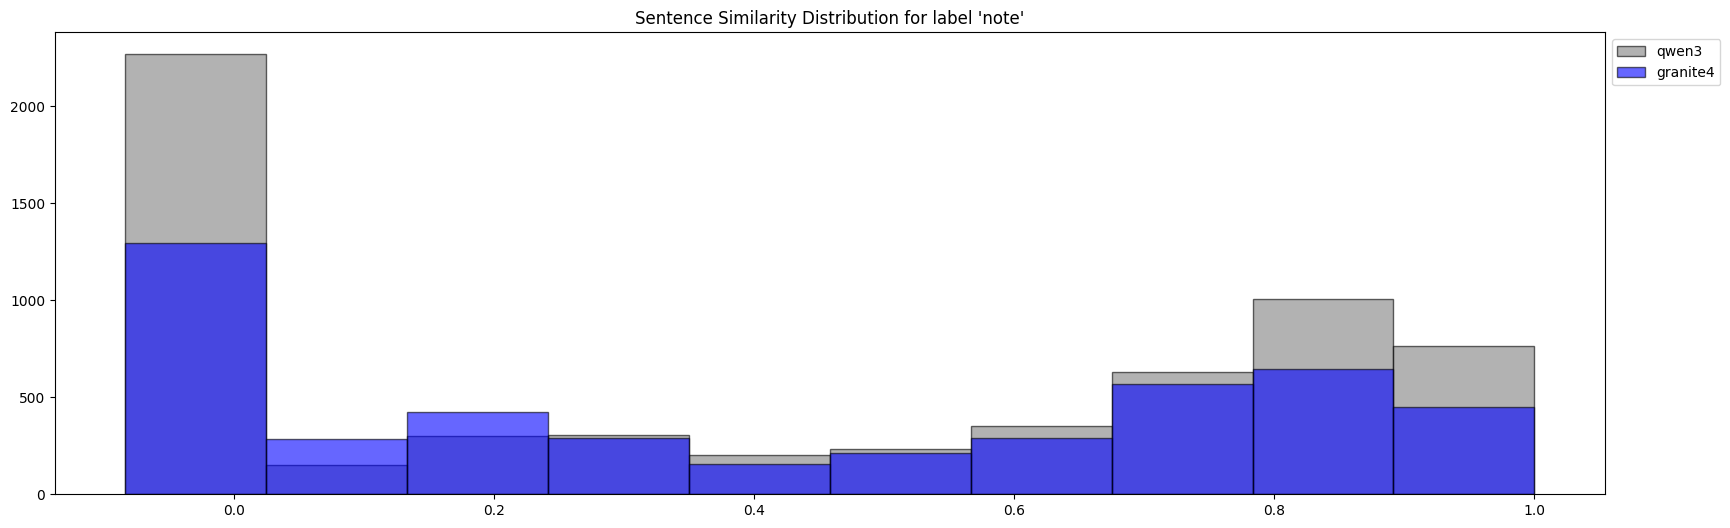

In [28]:
# distribuzione cosine similarity per il campo note
plt.figure(figsize=(20,6))
all_data = []
for model in models:
    data = df.loc[(df['model'] == model) & 
                  (df['TYPE_EVAL'] != 'edge_random') & 
                  (df['failure_reason'].isna()) & 
                  (df['sentence_similarity_score_note'].isna() != True)]['sentence_similarity_score_note']
    all_data.append(data)

min_val = min([d.min() for d in all_data])
max_val = max([d.max() for d in all_data])
bins = np.linspace(min_val, max_val, 11) ## 11 val -> 10 bin
for i, model in enumerate(models):
    plt.hist(all_data[i],
             bins=bins,  # Usa i bin espliciti invece di solo il numero
             histtype="bar",  # Cambiato da "barstacked"
             facecolor=colors[i],
             alpha=0.6,  # Aggiungi trasparenza per vedere sovrapposizioni
             label=model,
             edgecolor='black')
plt.title("Sentence Similarity Distribution for label 'note'")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

In [29]:
print(f" rows with score equal to zero / rows with score less or equal to zero -> {df.loc[(df['sentence_similarity_score_note'] == 0) ]['indice'].count()}/{df.loc[(df['sentence_similarity_score_note'] <= 0) ]['indice'].count()} -> {df.loc[(df['sentence_similarity_score_note'] == 0) ]['indice'].count() / df.loc[(df['sentence_similarity_score_note'] <= 0) ]['indice'].count()}")

 rows with score equal to zero / rows with score less or equal to zero -> 4378/4416 -> 0.9913949275362319


In [ ]:
import random
# controllo se il chat model si dimentica il testo lui oppure è l'extractor che dopo un pò sbaglia
random.choices(list(df.loc[(df['sentence_similarity_score_note'] == 0) ]['indice']), k=5)
# colpa chat: 13
# colpa extractor: 19

[1088, 864, 136, 414, 2775]

In [87]:
print(df.iloc[2775]['chat_context'])

{
  "chat-qwen3:4b-instruct": [],
  "chat-granite4:latest": [
    {
      "role": "user",
      "content": "Hoy complet\u00e9 8 horas de trabajo. Se realiz\u00f3 el cableado del secador grande y la nivelaci\u00f3n del lado motorizado del secador peque\u00f1o, con la colaboraci\u00f3n de 2 mec\u00e1nicos y 4 electricistas."
    },
    {
      "role": "assistant",
      "tool_calls": [
        {
          "type": "function",
          "function": {
            "index": 0,
            "name": "extractor_expert",
            "arguments": {
              "summary": "Hoy complet\u00e9 8 horas de trabajo. Se realiz\u00f3 el cableado del secador grande y la nivelaci\u00f3n del lado motorizado del secador peque\u00f1o, con la colaboraci\u00f3n de 2 mec\u00e1nicos y 4 electricistas."
            }
          }
        }
      ]
    },
    {
      "role": "assistant",
      "content": "\nHo riconosciuto i seguenti campi:\nore effetuate: 8.0\nore straordinarie: 0.0\nore di viaggio: 0.0\ncommessa: n


Vuol dire che il campo note predetto è vuoto quando nella true label è presente oppure la nota è completamente sbagliata. Vuol dire che il modello cattura le ore da segnare ma si "scorda" di catturare anche le note oppure le perde durante la conversazione.
 

In [153]:
# cosine similarity campo inefficiency desciption
df_prova = add_similarity(df, "sentence_similarity_score_inefficiency", "inefficiency_note_true","inefficiency_note_predict","sentence_similarity")

100%|██████████| 4240/4240 [09:30<00:00,  7.43it/s]


In [156]:
df['sentence_similarity_score_inefficiency'] = df_prova['sentence_similarity_score_inefficiency']

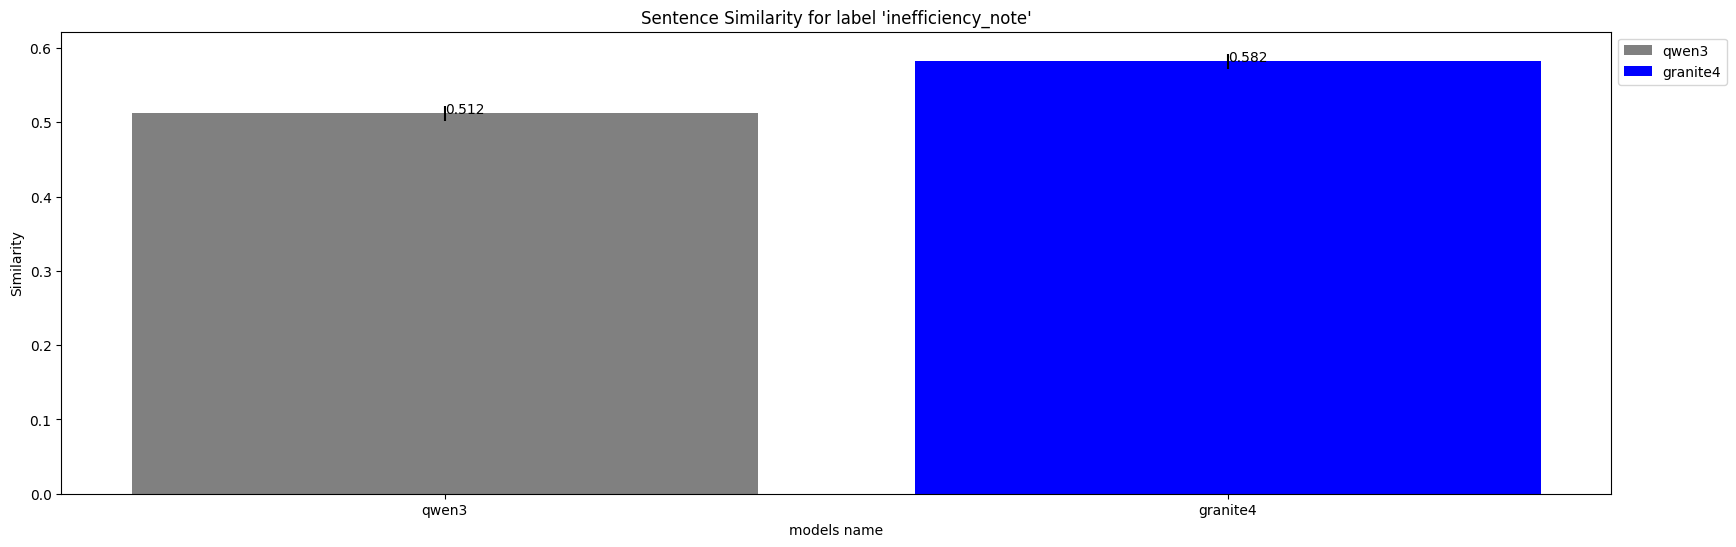

In [182]:
# cosine similarity campo inefficiency desciption
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])
media_group = []
CI_group = []
for model in models:
    acc_media = round(df.loc[(df['model'] == model) & (df['TYPE_EVAL'] != 'edge_random') & (df['failure_reason'].isna()) & (df['sentence_similarity_score_inefficiency'].isna() != True)]['sentence_similarity_score_inefficiency'].mean(),3)
    n = len(df)
    # intervallo di confidenza al 99 %
    CI = 2.576 * np.sqrt(acc_media * (1- acc_media) / n)
    media_group.append(acc_media)
    CI_group.append(CI)

plt.figure(figsize=(20,6))
plt.bar(models, media_group, yerr=CI_group, color=colors, label=models)
add_labels(models,media_group)
plt.title("Sentence Similarity for label 'inefficiency_note'")
plt.xlabel("models name")
plt.ylabel("Similarity")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

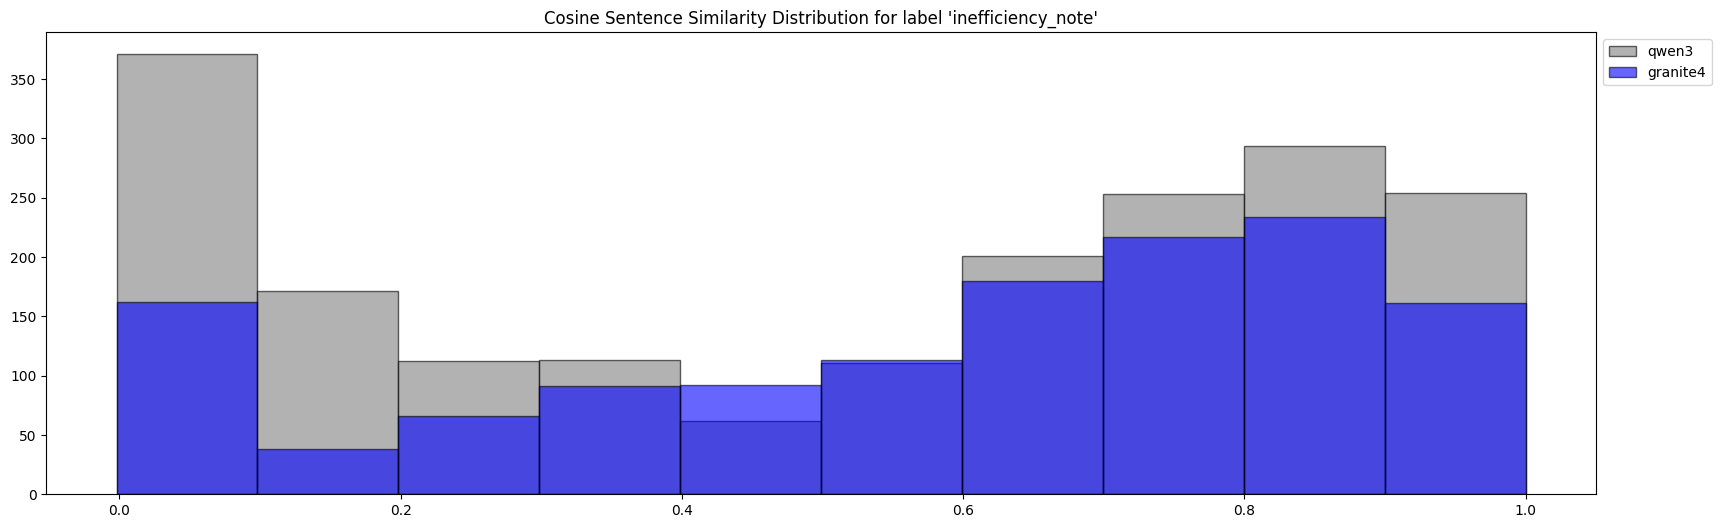

In [ ]:
# distribuzione cosine similarity per il campo inefficiency note
plt.figure(figsize=(20,6))
all_data = []
for model in models:
    data = df.loc[(df['model'] == model) & 
                  (df['TYPE_EVAL'] != 'edge_random') & 
                  (df['failure_reason'].isna()) & 
                  (df['sentence_similarity_score_inefficiency'].isna() != True)]['sentence_similarity_score_inefficiency']
    all_data.append(data)

min_val = min([d.min() for d in all_data])
max_val = max([d.max() for d in all_data])
bins = np.linspace(min_val, max_val, 11) ## 11 val -> 10 bin
for i, model in enumerate(models):
    plt.hist(all_data[i],
             bins=bins,  # Usa i bin espliciti invece di solo il numero
             histtype="bar",  # Cambiato da "barstacked"
             facecolor=colors[i],
             alpha=0.6,  # Aggiungi trasparenza per vedere sovrapposizioni
             label=model,
             edgecolor='black')
plt.title("Cosine Sentence Similarity Distribution for label 'inefficiency_note'")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

## Final Recap

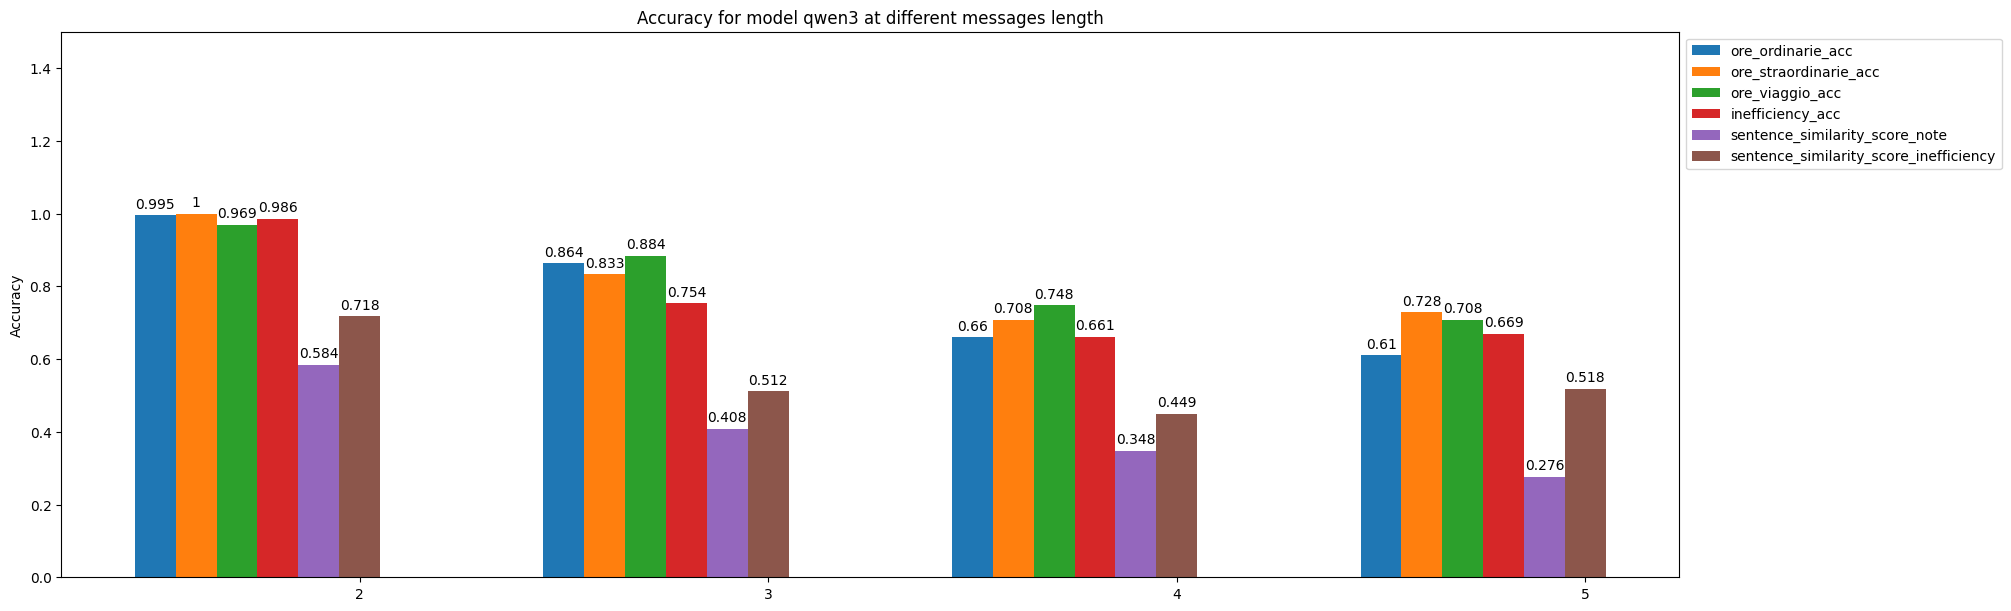

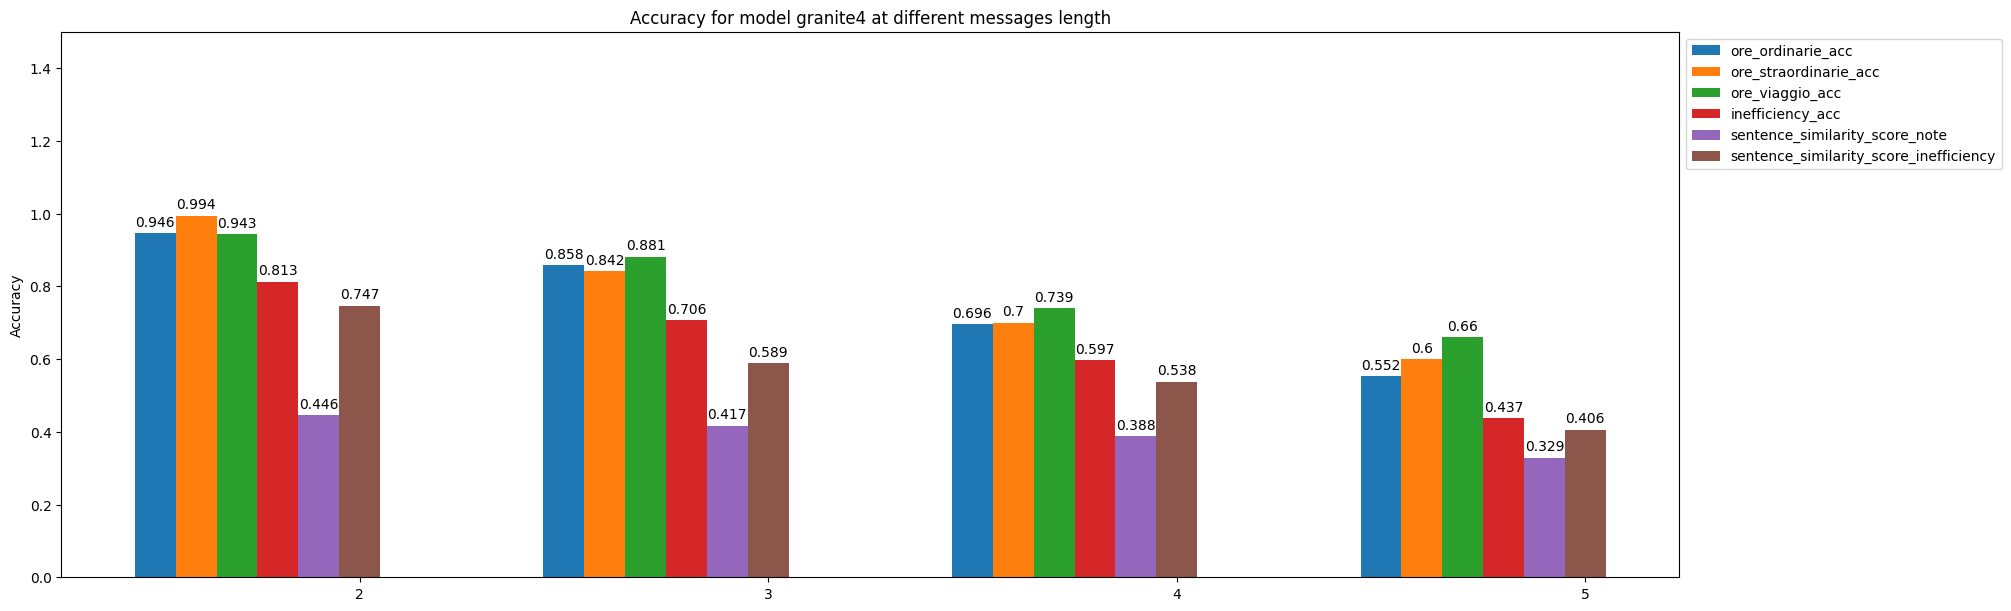

In [36]:
# chart per fare il display accuracy totale  al variare del flow

# senza la l = 1 perchè è un edge case quello
l_msg = np.sort(df['L_MESSAGGI'].unique())[1:]
for model in models:
    metric_means = {}
    columns = ['ore_ordinarie_acc', 'ore_straordinarie_acc', 'ore_viaggio_acc','inefficiency_acc','sentence_similarity_score_note','sentence_similarity_score_inefficiency']
    # init il dict
    for column in columns:
        metric_means[column] = ()

    for length_m in l_msg:
        for column in columns:
            if column == 'sentence_similarity_score_inefficiency' or column == 'sentence_similarity_score_note':
                ris = (round(df.loc[(df['model'] == model) & (df['TYPE_EVAL'] != 'edge_random') & (df['failure_reason'].isna()) & (df[column].isna() != True) & (df['L_MESSAGGI'] == length_m)][column].mean(),3),)
                metric_means[column] += ris
            else:
                ris = (round(df.loc[(df['model'] == model) & (df['TYPE_EVAL'] != 'edge_random') & (df['failure_reason'].isna()) & (df['L_MESSAGGI'] == length_m)][column].mean(),3),)
                metric_means[column] += ris
    
    x = np.arange(len(l_msg))  # the label locations
    width = 0.10  # the width of the bars
    multiplier = 0
    fig, ax = plt.subplots(figsize=(20,6), layout='constrained')
    for attribute, measurement in metric_means.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, padding=3)
        
        # inseriamo l'accuracy media
        """ if attribute == 'ore_viaggio_acc':
            x_pos = x + offset
            for x in x_pos:
                ax.text(x, 1.1,'prova') """

        multiplier += 1
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Accuracy for model {model} at different messages length')
    ax.set_xticks(x + offset, l_msg)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
    ax.set_ylim(0, 1.5)

In [ ]:
# salviamo per fare altre analisi in futuro
#df.to_csv("results_with_similarity_text.csv", index=False)

## Failure Analysis

In [9]:
df['failure_reason'].notna().sum()

np.int64(2534)

In [20]:
df.columns

Index(['indice', 'model', 'language', 'messaggi', 'ore_ordinarie_true',
       'ore_straordinarie_true', 'ore_viaggio_true', 'note_true',
       'inefficiency_true', 'inefficiency_note_true', 'chat_context',
       'context_window', 'function_calls', 'push_data_response',
       'ore_ordinarie_acc', 'ore_straordinarie_acc', 'ore_viaggio_acc',
       'inefficiency_acc', 'tot_acc', 'total_duration', 'load_duration_chat',
       'prompt_eval_duration_chat', 'eval_duration_chat', 'eval_count_chat',
       'load_duration_extractor', 'prompt_eval_duration_extractor',
       'eval_duration_extractor', 'eval_count_extractor',
       'ore_ordinarie_predict', 'ore_straordinarie_predict',
       'ore_viaggio_predict', 'note_predict', 'inefficiency_predict',
       'inefficiency_note_predict', 'REF_INDICE', 'L_MESSAGGI', 'TYPE_EVAL',
       'W_MESSAGGI', 'count_function_calls', 'failure_reason'],
      dtype='object')

In [22]:
df.loc[(df['language'] == 'italian') & (df['failure_reason'].isna() == False)][['chat_context', 'ore_ordinarie_true', 'ore_straordinarie_true', 'ore_viaggio_true', 'note_true',
       'inefficiency_true', 'inefficiency_note_true']].to_csv("../data/training_dataset/train/italian_failure.csv")

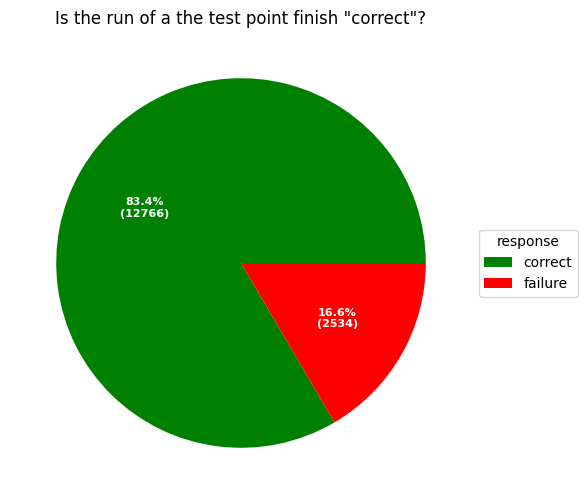

In [247]:
fig, ax = plt.subplots(figsize=(20, 6), subplot_kw=dict(aspect="equal"))

def func(pct,all):
    absolute = int(np.round(pct/100.*np.sum(all)))
    return f"{pct:.1f}%\n({absolute})"

dict_results = {'correct': df['failure_reason'].isna().sum(), 'failure':df['failure_reason'].notna().sum()}
data = dict_results.values()
labels = dict_results.keys()
wedges, texts, autotexts = ax.pie(data, autopct=lambda pct: func(pct,list(data)),colors=['green', 'red'],
                                  textprops=dict(color="w"))

ax.legend(wedges,labels,
          title="response",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))

plt.setp(autotexts, size=8, weight="bold")

ax.set_title('Is the run of a the test point finish "correct"?')
plt.show()

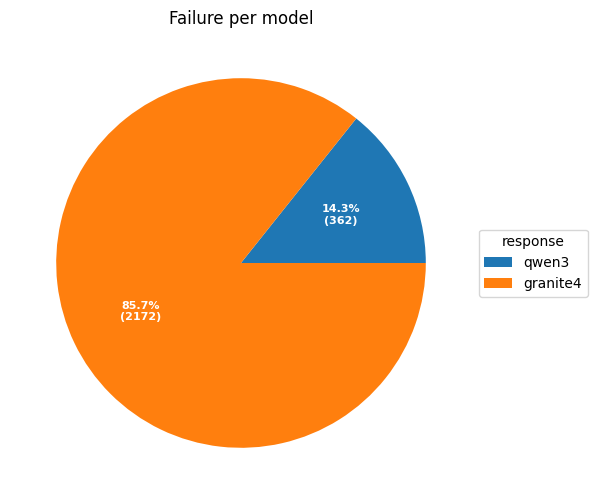

In [248]:
# failure rate per model
fig, ax = plt.subplots(figsize=(20, 6), subplot_kw=dict(aspect="equal"))

def func(pct,all):
    absolute = int(np.round(pct/100.*np.sum(all)))
    return f"{pct:.1f}%\n({absolute})"

dict_results = {'qwen3': df.loc[df['model'] == 'qwen3']['failure_reason'].notna().sum(), 'granite4': df.loc[df['model'] == 'granite4']['failure_reason'].notna().sum()}
data = dict_results.values()
labels = dict_results.keys()
wedges, texts, autotexts = ax.pie(data, autopct=lambda pct: func(pct,list(data)),
                                  textprops=dict(color="w"))

ax.legend(wedges,labels,
          title="response",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))

plt.setp(autotexts, size=8, weight="bold")

ax.set_title('Failure per model')
plt.show()

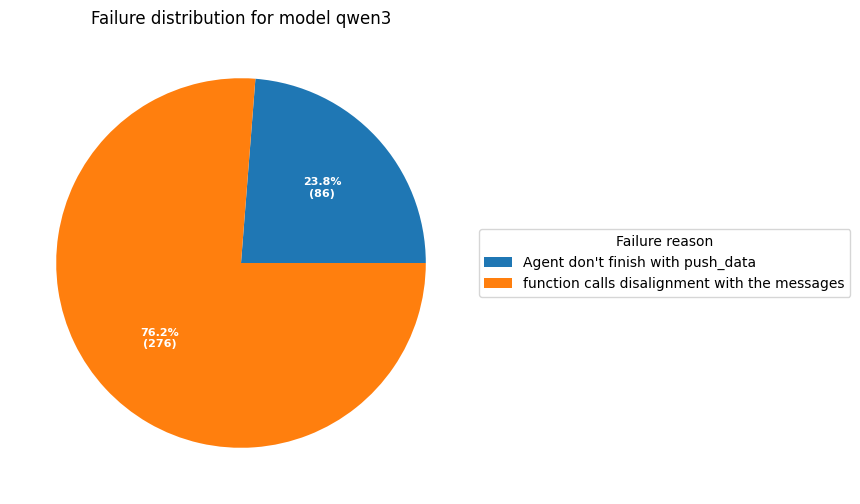

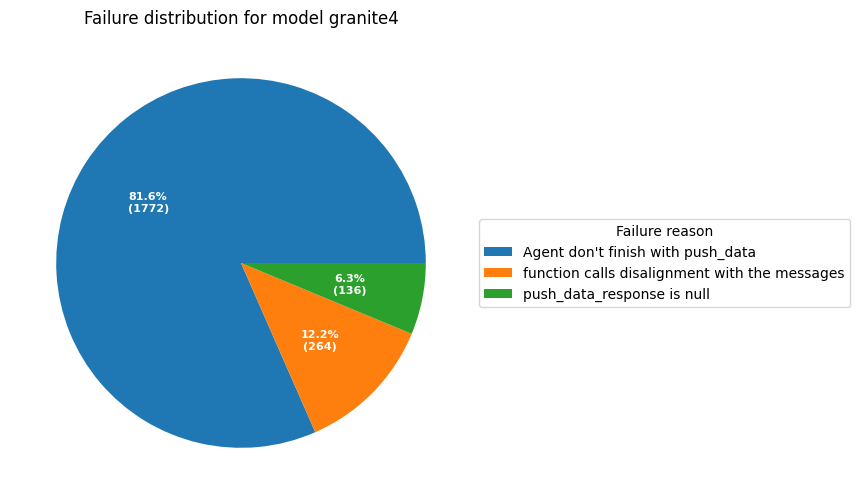

In [249]:
# pei chart sulle tipologie di failure

for model in models:
    fig, ax = plt.subplots(figsize=(20, 6), subplot_kw=dict(aspect="equal"))


    def func(pct,all):
        absolute = int(np.round(pct/100.*np.sum(all)))
        return f"{pct:.1f}%\n({absolute})"

    dict_results = dict(df.loc[df['model'] == model].groupby(['failure_reason'])['indice'].count())
    data = dict_results.values()
    labels = dict_results.keys()
    wedges, texts, autotexts = ax.pie(data, autopct=lambda pct: func(pct,list(data)),
                                      textprops=dict(color="w"))

    ax.legend(wedges,labels,
              title="Failure reason",
              loc="center left",
              bbox_to_anchor=(1, 0, 0.5, 1))

    plt.setp(autotexts, size=8, weight="bold")

    ax.set_title(f"Failure distribution for model {model}")
    plt.show()

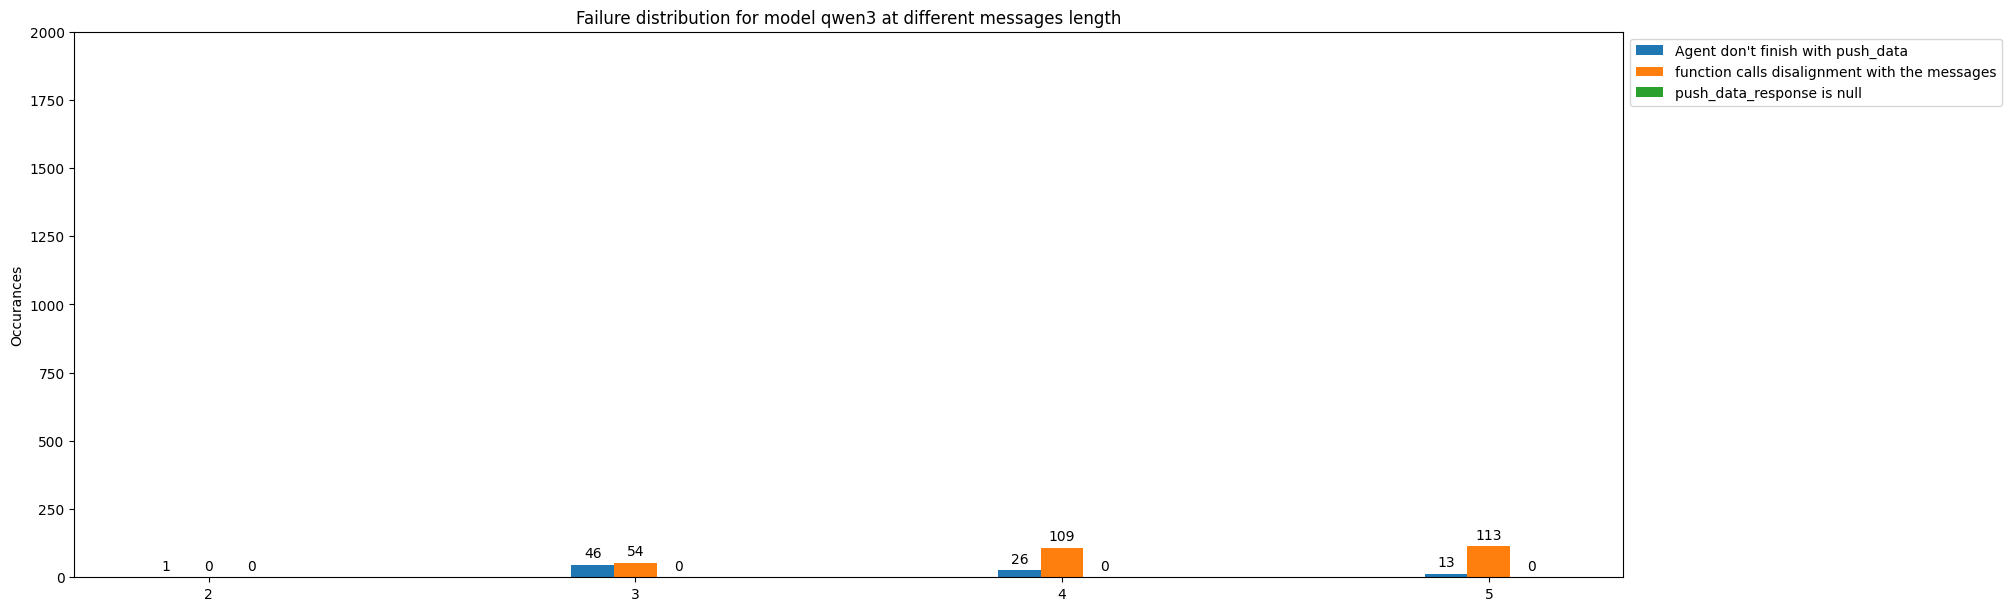

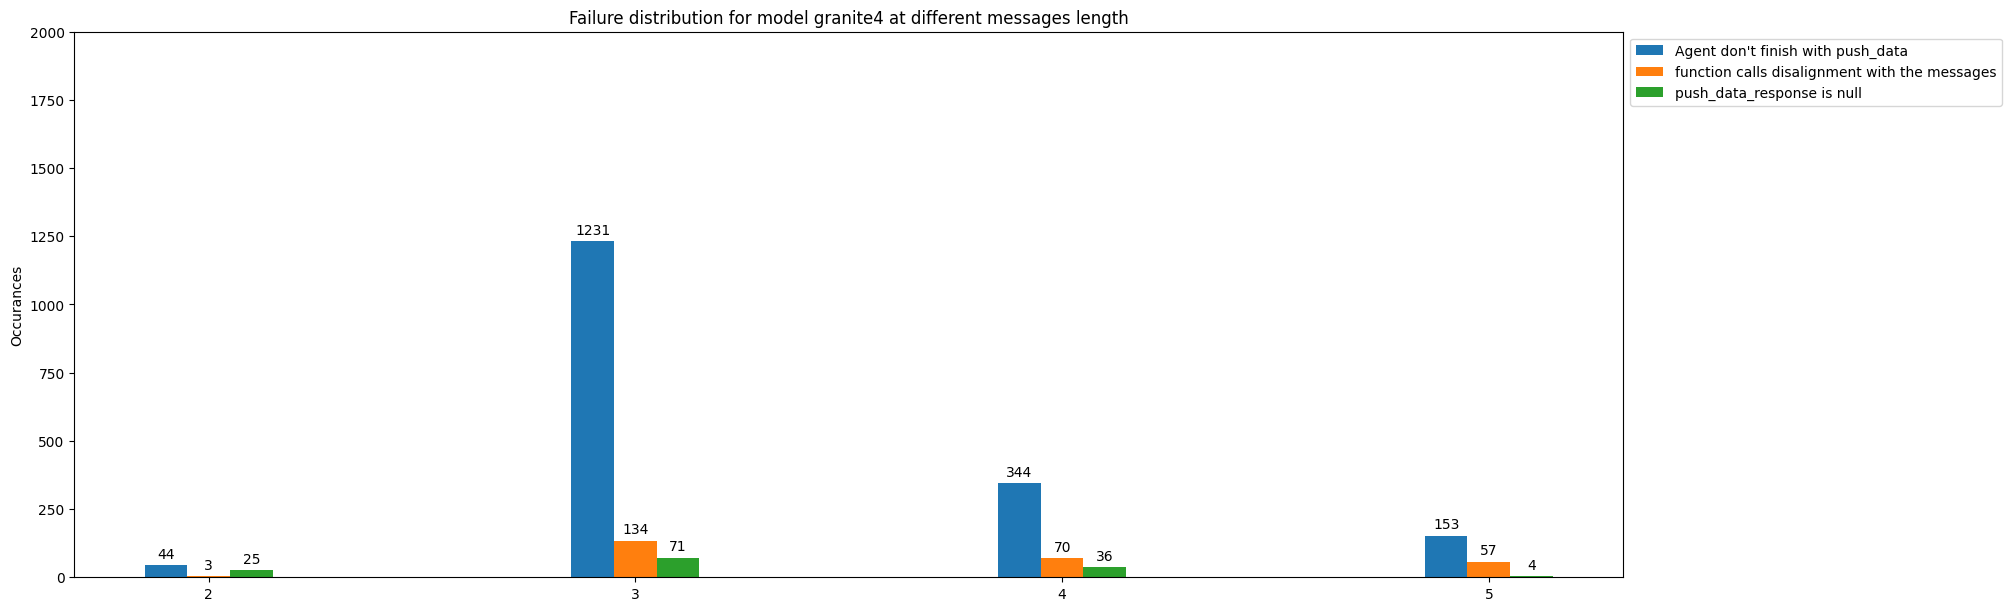

In [250]:
# distribuzione tipologie di failure con diversi livelli di flow
l_msg = np.sort(df['L_MESSAGGI'].unique())[1:]
for model in models:
    metric_means = {}
    columns = list(dict(df.groupby(['failure_reason'])['indice'].count()).keys())
    # init il dict
    for column in columns:
        metric_means[column] = ()

    for length_m in l_msg:
        for column in columns:
                ris = (df.loc[(df['model'] == model) & (df['failure_reason'] == column) & (df['L_MESSAGGI'] == length_m)]['indice'].count(),)
                metric_means[column] += ris
    
    x = np.arange(len(l_msg))  # the label locations
    width = 0.10  # the width of the bars
    multiplier = 0
    fig, ax = plt.subplots(figsize=(20,6), layout='constrained')
    for attribute, measurement in metric_means.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, padding=3)
        multiplier += 1
    ax.set_ylabel('Occurances')
    ax.set_title(f'Failure distribution for model {model} at different messages length')
    ax.set_xticks(x + width, l_msg)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
    ax.set_ylim(0, 2000)

## Context Window Analysis

In [5]:
import json
def compute_tokens(conversation_json, model):
    """Calcola i token della conversazione"""
    total_tokens = 0
    
    for key in conversation_json.keys():
        if conversation_json[key]:
            for message in conversation_json[key]:
                # Conta i token del contenuto del messaggio
                print(f"messaggio: {message}")
                if 'content' in message and message['content']:
                    model_response = model.tokenize(text=message['content'])
        
                    if 'tokens' in model_response:
                        total_tokens += len(model_response['tokens'])
                    else:
                        raise Exception(f"Errore nella response del modello: {model_response}")
                
                # Conta i token delle tool_calls (se presenti)
                if 'tool_calls' in message:
                    for tool_call in message['tool_calls']:
                        # Serializza la tool call come stringa
                        tool_str = json.dumps(tool_call)
                        model_response = model.tokenize(text=tool_str)
                        if 'tokens' in model_response:
                            total_tokens += len(model_response['tokens'])
                        else:
                            raise Exception(f"Errore nella response del modello: {model_response}")
    
    print(f'total tokens: {total_tokens}')
    return total_tokens

In [ ]:
conversation = json.loads(df.loc[2821, 'chat_context'])


 chat-qwen3:4b-instruct non ha un valore
 chat-granite4:latest ha un valore


In [6]:
# calcolo token processati dal chat_context
import sys
import os

# Aggiungi la cartella padre al path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

from OllamaHttpClient import OllamaClient
from tqdm import tqdm
import json
from omegaconf import OmegaConf
conf = OmegaConf.load("../config.yaml")

client = OllamaClient(conf)

for i in tqdm(df.loc[df['model'] == 'granite4'].index):
    model = 'granite4:latest' 
    if model:
        client.add_model(model)
        conversation = json.loads(df.loc[i, 'chat_context'])
        # aggiorniamo la context window
        df.loc[i, 'context_window'] = compute_tokens(conversation,client)


2025-12-10 09:25:18,842 - INFO - [OllamaHttpClient.py:47] - ✅ Server Ollama raggiungibile - 11 modelli disponibili
2025-12-10 09:25:18,843 - INFO - [OllamaHttpClient.py:48] -    URL: http://172.18.31.178:11434
2025-12-10 09:25:18,844 - INFO - [OllamaHttpClient.py:53] -    📦 wizardlm2:7b (3918.6 MB)
2025-12-10 09:25:18,844 - INFO - [OllamaHttpClient.py:53] -    📦 ibm/granite4:tiny-h (4035.0 MB)
2025-12-10 09:25:18,845 - INFO - [OllamaHttpClient.py:53] -    📦 ibm/granite4:small-h (18574.4 MB)
2025-12-10 09:25:18,846 - INFO - [OllamaHttpClient.py:53] -    📦 extractor-granite4:latest (2002.3 MB)
2025-12-10 09:25:18,847 - INFO - [OllamaHttpClient.py:53] -    📦 extractor-qwen3:4b-instruct (2381.6 MB)
2025-12-10 09:25:18,847 - INFO - [OllamaHttpClient.py:53] -    📦 chat-granite4:latest (2002.3 MB)
2025-12-10 09:25:18,848 - INFO - [OllamaHttpClient.py:53] -    📦 chat-qwen3:4b-instruct (2381.6 MB)
2025-12-10 09:25:18,848 - INFO - [OllamaHttpClient.py:53] -    📦 gpt-oss:latest (13154.5 MB)
2025-

messaggio: {'role': 'user', 'content': 'Ieri ho lavorato otto ore, ho verificato i moduli PLC A4, A6, E6 e E7 per le zone 14, 12 e 10, modificato i collegamenti dei sensori di rallentamento e del fine corsa della traslazione rulliera 12, e ho svolto prove di funzionamento e sviluppo del software di velocità per le zone 10, 12 e 14.'}


Exception: Errore nella response del modello: {'error': '404 Client Error: Not Found for url: http://172.18.31.178:11434/api/tokenize'}

C:\Users\nicolo.rossi\AppData\Local\Temp\ipykernel_26088\3943638024.py:15: RuntimeWarning: invalid value encountered in sqrt
  CI = 2.576 * np.sqrt(acc_media * (1- acc_media) / n)


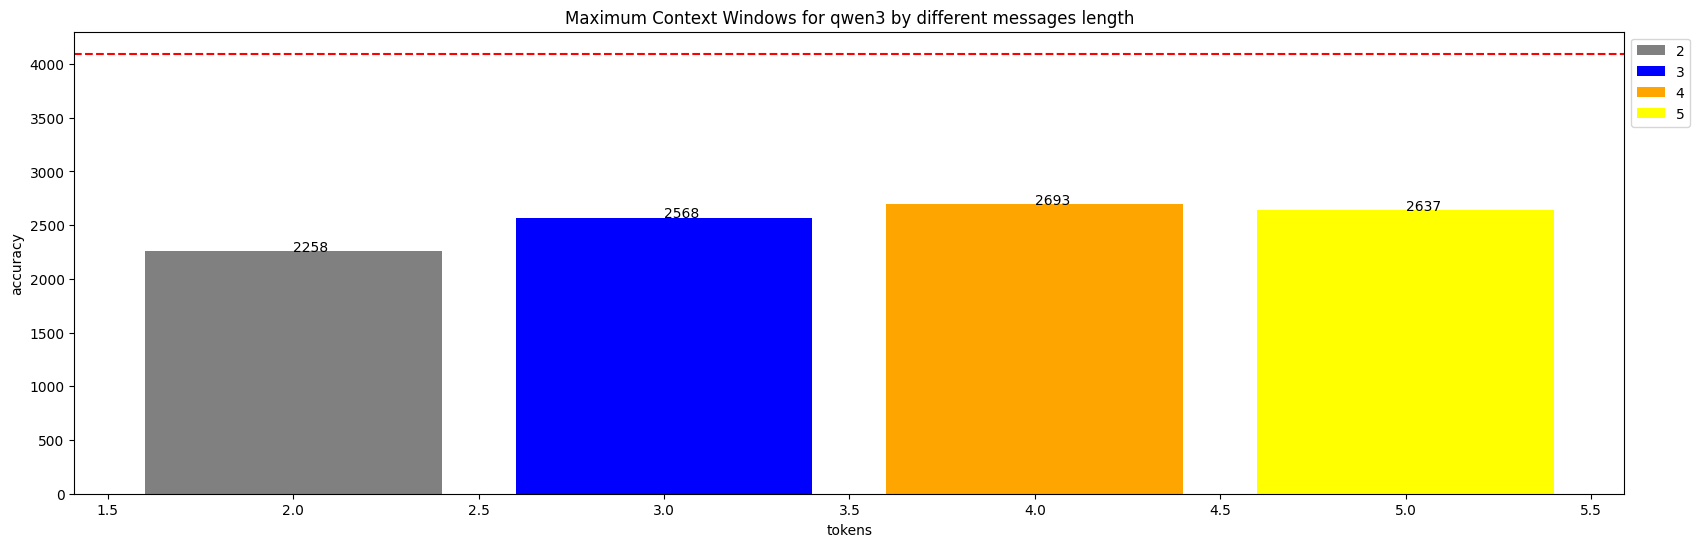

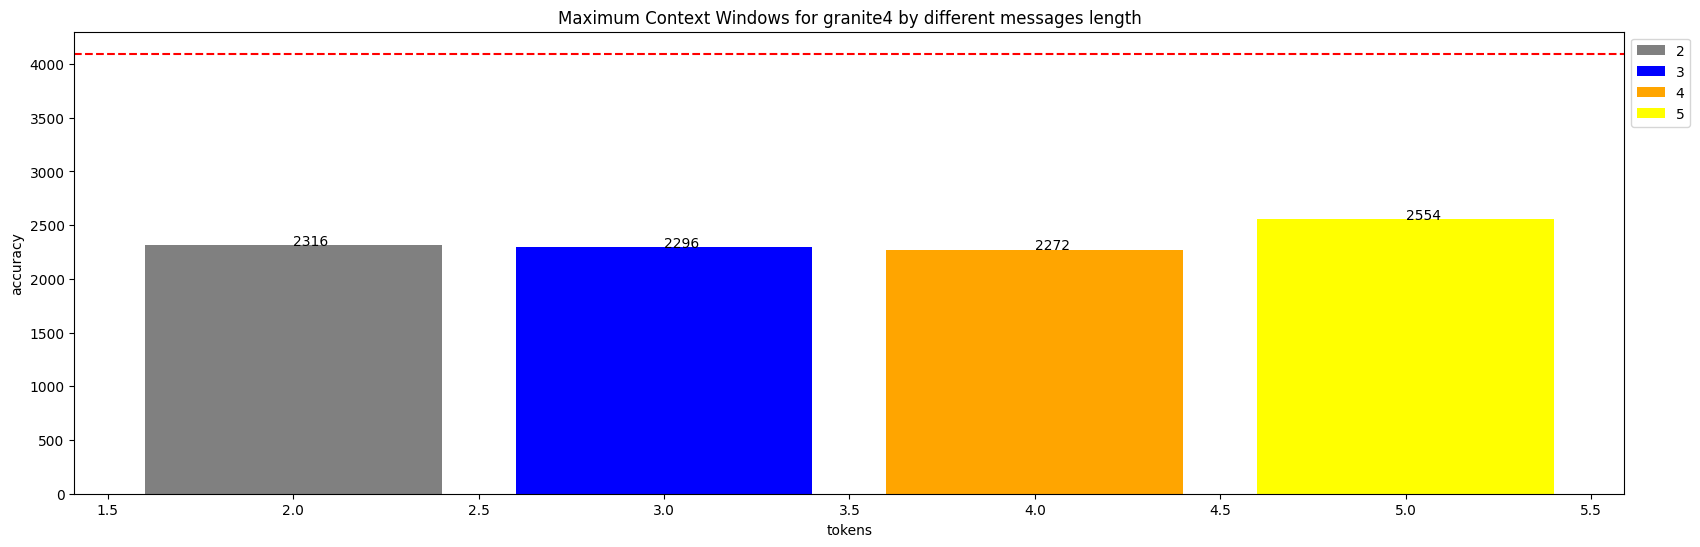

In [255]:
# chart per mostrare la context window per i diversi livelli di flow
def add_labels(labels, vals):
    for i,x_label in enumerate(labels):
        plt.text(x_label,vals[i], vals[i])

# senza la l = 1 perchè è un edge case quello
l_msg = np.sort(df['L_MESSAGGI'].unique())[1:]
for model in models:
    media_group = []
    CI_group = []
    for length_m in l_msg:
        acc_media = round(df.loc[(df['model'] == model) & (df['TYPE_EVAL'] != 'edge_random') & (df['failure_reason'].isna()) & (df['L_MESSAGGI'] == length_m)]['context_window'].max(),3)
        n = len(df)
        # intervallo di confidenza al 99 %
        CI = 2.576 * np.sqrt(acc_media * (1- acc_media) / n)
        media_group.append(acc_media)
        CI_group.append(CI)

    plt.figure(figsize=(20,6))
    plt.bar(l_msg,media_group, yerr=CI_group, color=colors, label=l_msg)
    add_labels(l_msg,media_group)
    plt.title(f"Maximum Context Windows for {model} by different messages length")
    plt.xlabel("tokens")
    plt.ylabel("accuracy")
    plt.axhline(y=4096, color='r',linestyle='--')
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

## Analisi Lingua 

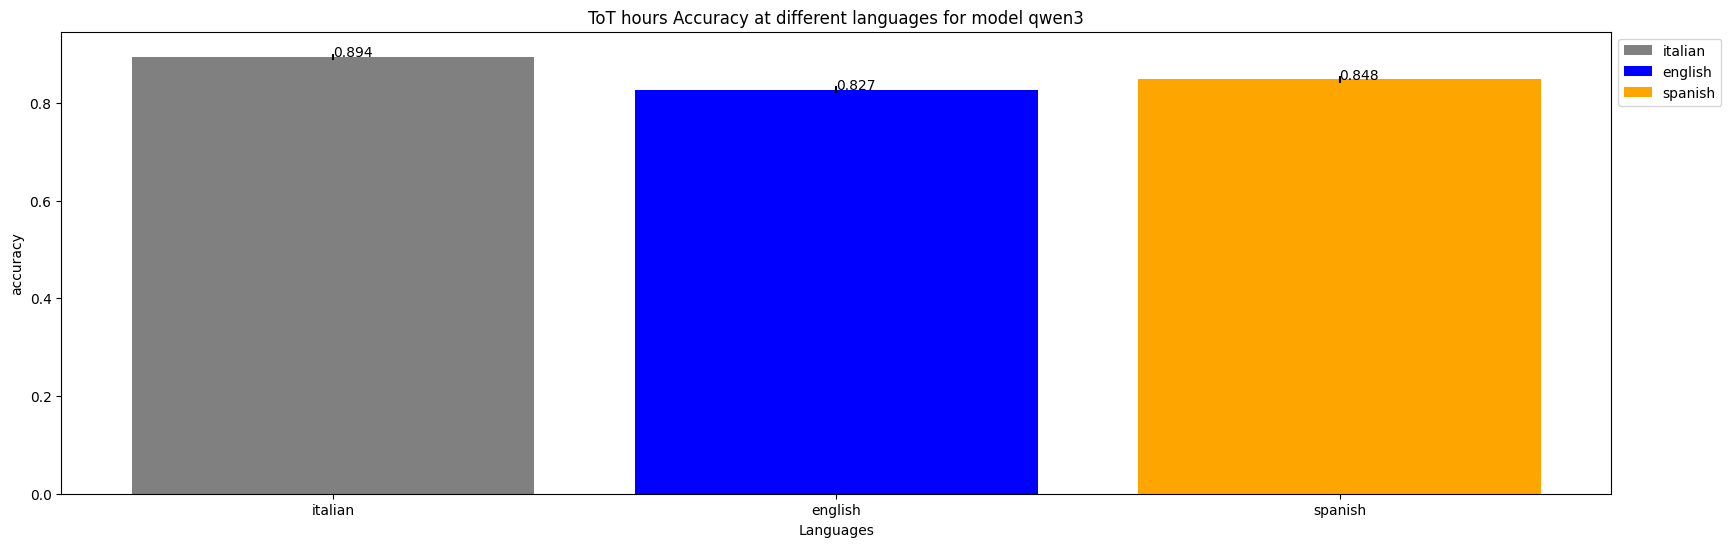

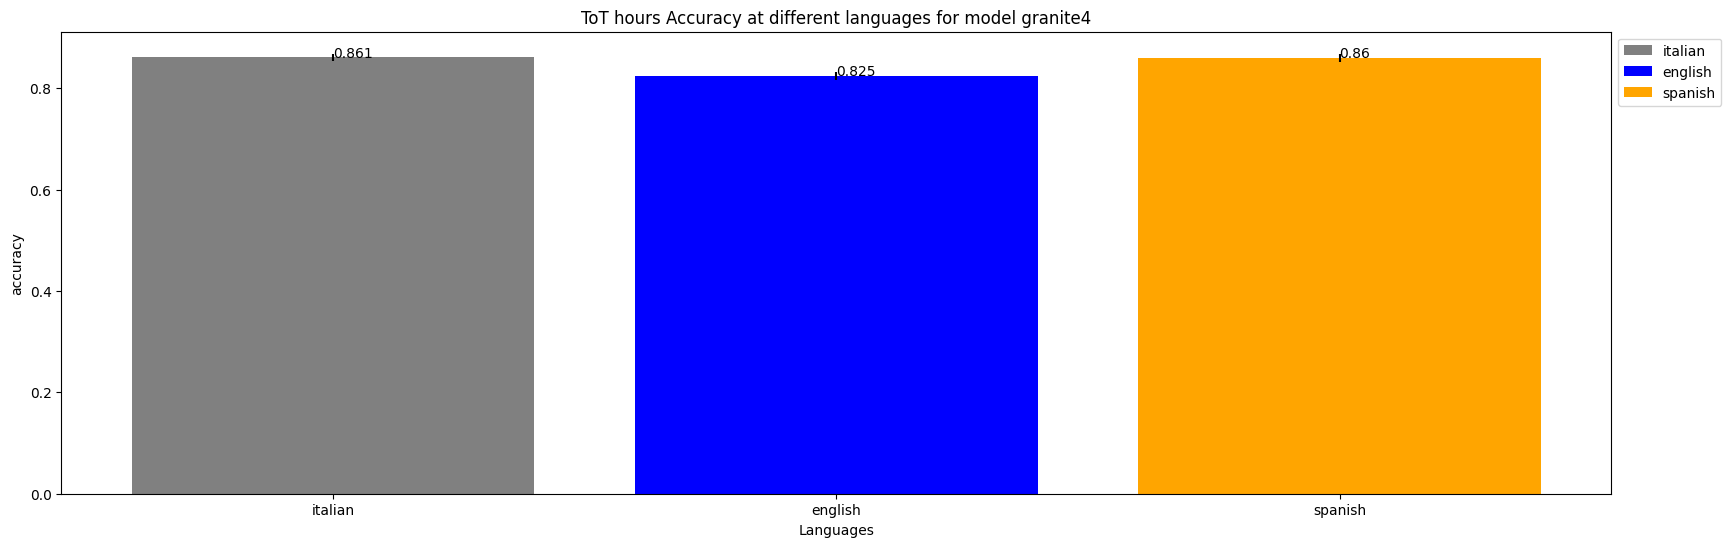

In [9]:
# accuracy tot per lingua
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])

languages = df['language'].unique()


for model in models:
    media_group = []
    CI_group = []
    for language in languages:
        acc_media = round(df.loc[(df['model'] == model) & (df['TYPE_EVAL'] != 'edge_random') & (df['failure_reason'].isna()) & (df['language'] == language)]['tot_acc'].mean(),3)
        n = len(df)
        # intervallo di confidenza al 99 %
        CI = 2.576 * np.sqrt(acc_media * (1- acc_media) / n)
        media_group.append(acc_media)
        CI_group.append(CI)
    plt.figure(figsize=(20,6))
    plt.bar(languages, media_group, yerr=CI_group, color=colors, label=languages)
    add_labels(languages,media_group)
    plt.title(f"ToT hours Accuracy at different languages for model {model}")
    plt.xlabel("Languages")
    plt.ylabel("accuracy")
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))